In [1]:
from utils.utils import *
from utils.strategies import *
from utils.align import *
from utils.ensemble import *
from utils.tpsl import *
from utils.backtester import *

In [2]:
config = load_yaml('config.yaml')

# Insample
    start_date: '2018-01-01' | end_date: '2022-01-12'

In [3]:
ohlcv_cheby, ohlcv_gmma_1w, ohlcv_gmma_1d, ohlcv_gran = load_ohlcv_data(config)

In [4]:
strat_cheby = StratCheby(ohlcv_cheby, ohlcv_gran, config)
cheby_trades = strat_cheby.run()

In [5]:
strat_gmma = MixedStratGMMA(ohlcv_gmma_1w, ohlcv_gmma_1d, ohlcv_gran, config)
gmma_trades, gmma_values = strat_gmma.run()

In [6]:
aligner = Aligner(cheby_trades, gmma_trades, config)
aligned_cheby_trades, aligned_gmma_trades = aligner.run()

In [7]:
ensemble = Ensemble(aligned_cheby_trades, aligned_gmma_trades, gmma_values, config)
ensemble_trades = ensemble.run()

100%|██████████| 704310/704310 [02:04<00:00, 5670.94it/s] 


In [8]:
tpsl = TPSL(config)
tpsl_trades = tpsl.run(ensemble_trades)

Gross profit: 11858.78644608567
Net profit: 5436.275626096111
Total closed trades: 223.0
Win rate: 48.4304932735426 %
Max dip: 21.827009695396605 %
Max runup: 97.35424955028726 %
Gross loss: 6280.798207930649
Average winning trade: 109.18527839974051
Average losing trade: -55.26725600935534
Buy and hold return of BTC: 211.22536710960122
Largest winning trade: 1656.5596519692494
Largest losing trade: -504.18257259246366
Sharpe ratio: 4.149193011086819
Sortino ratio: 15.922862378333187
Average holding duration: 4 days 08:42:22.600896861
Max drawdown: -34.5471986091404


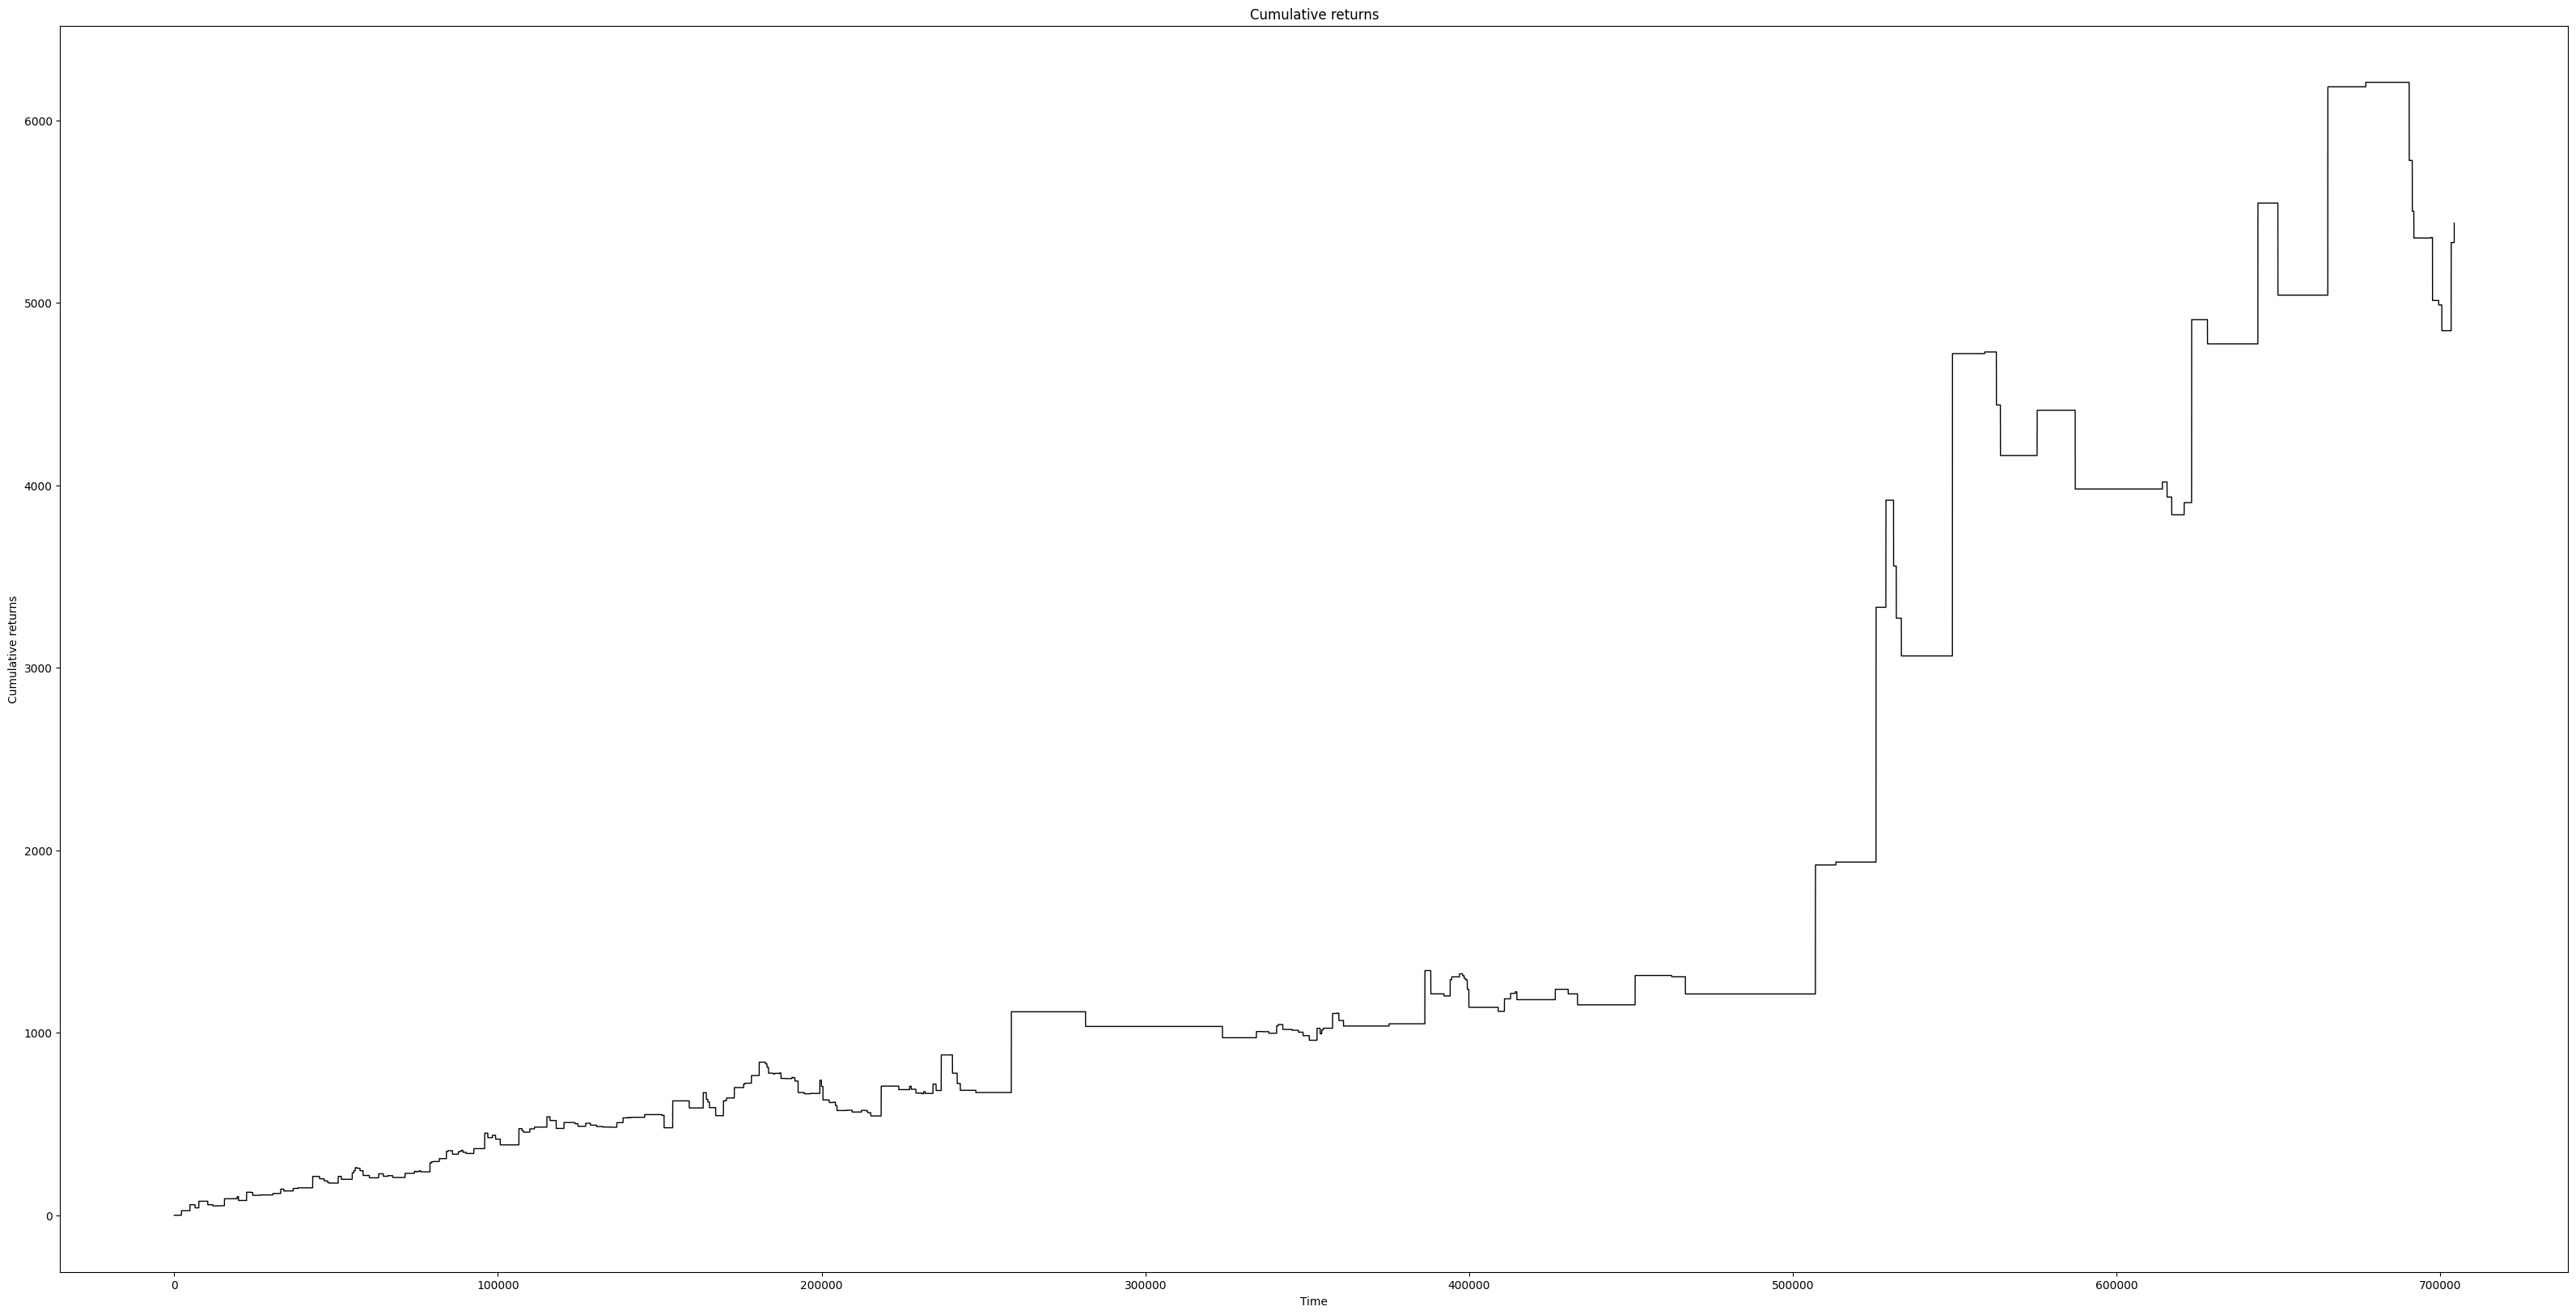

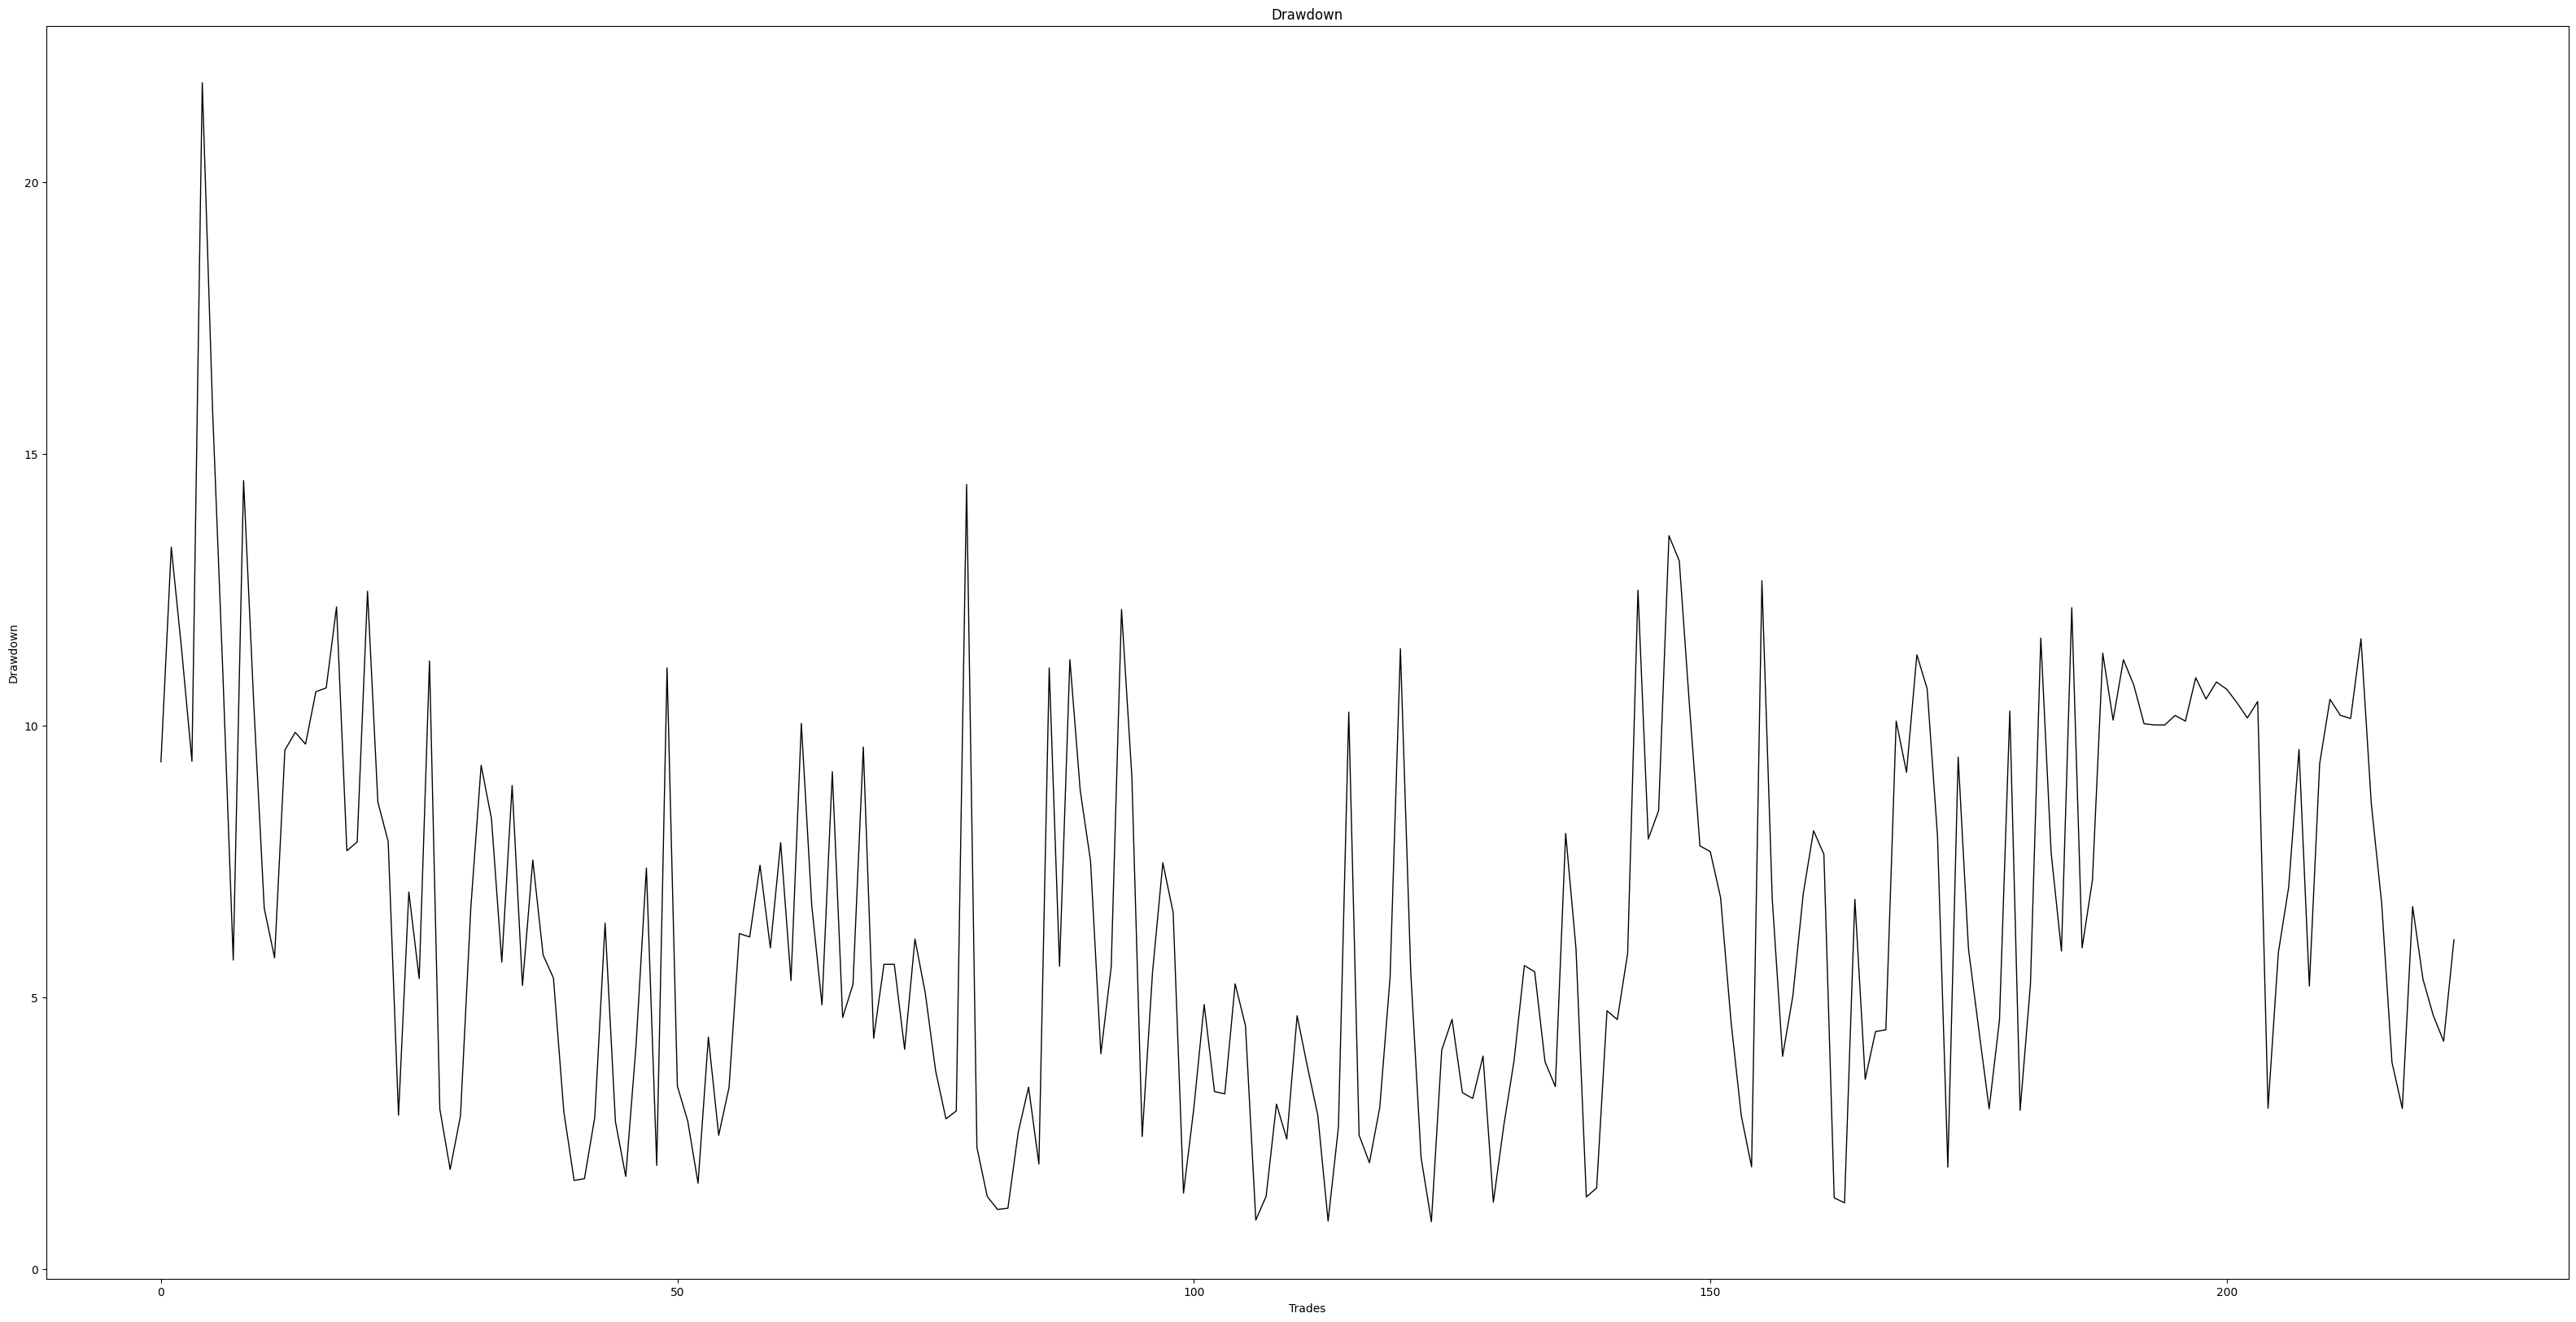

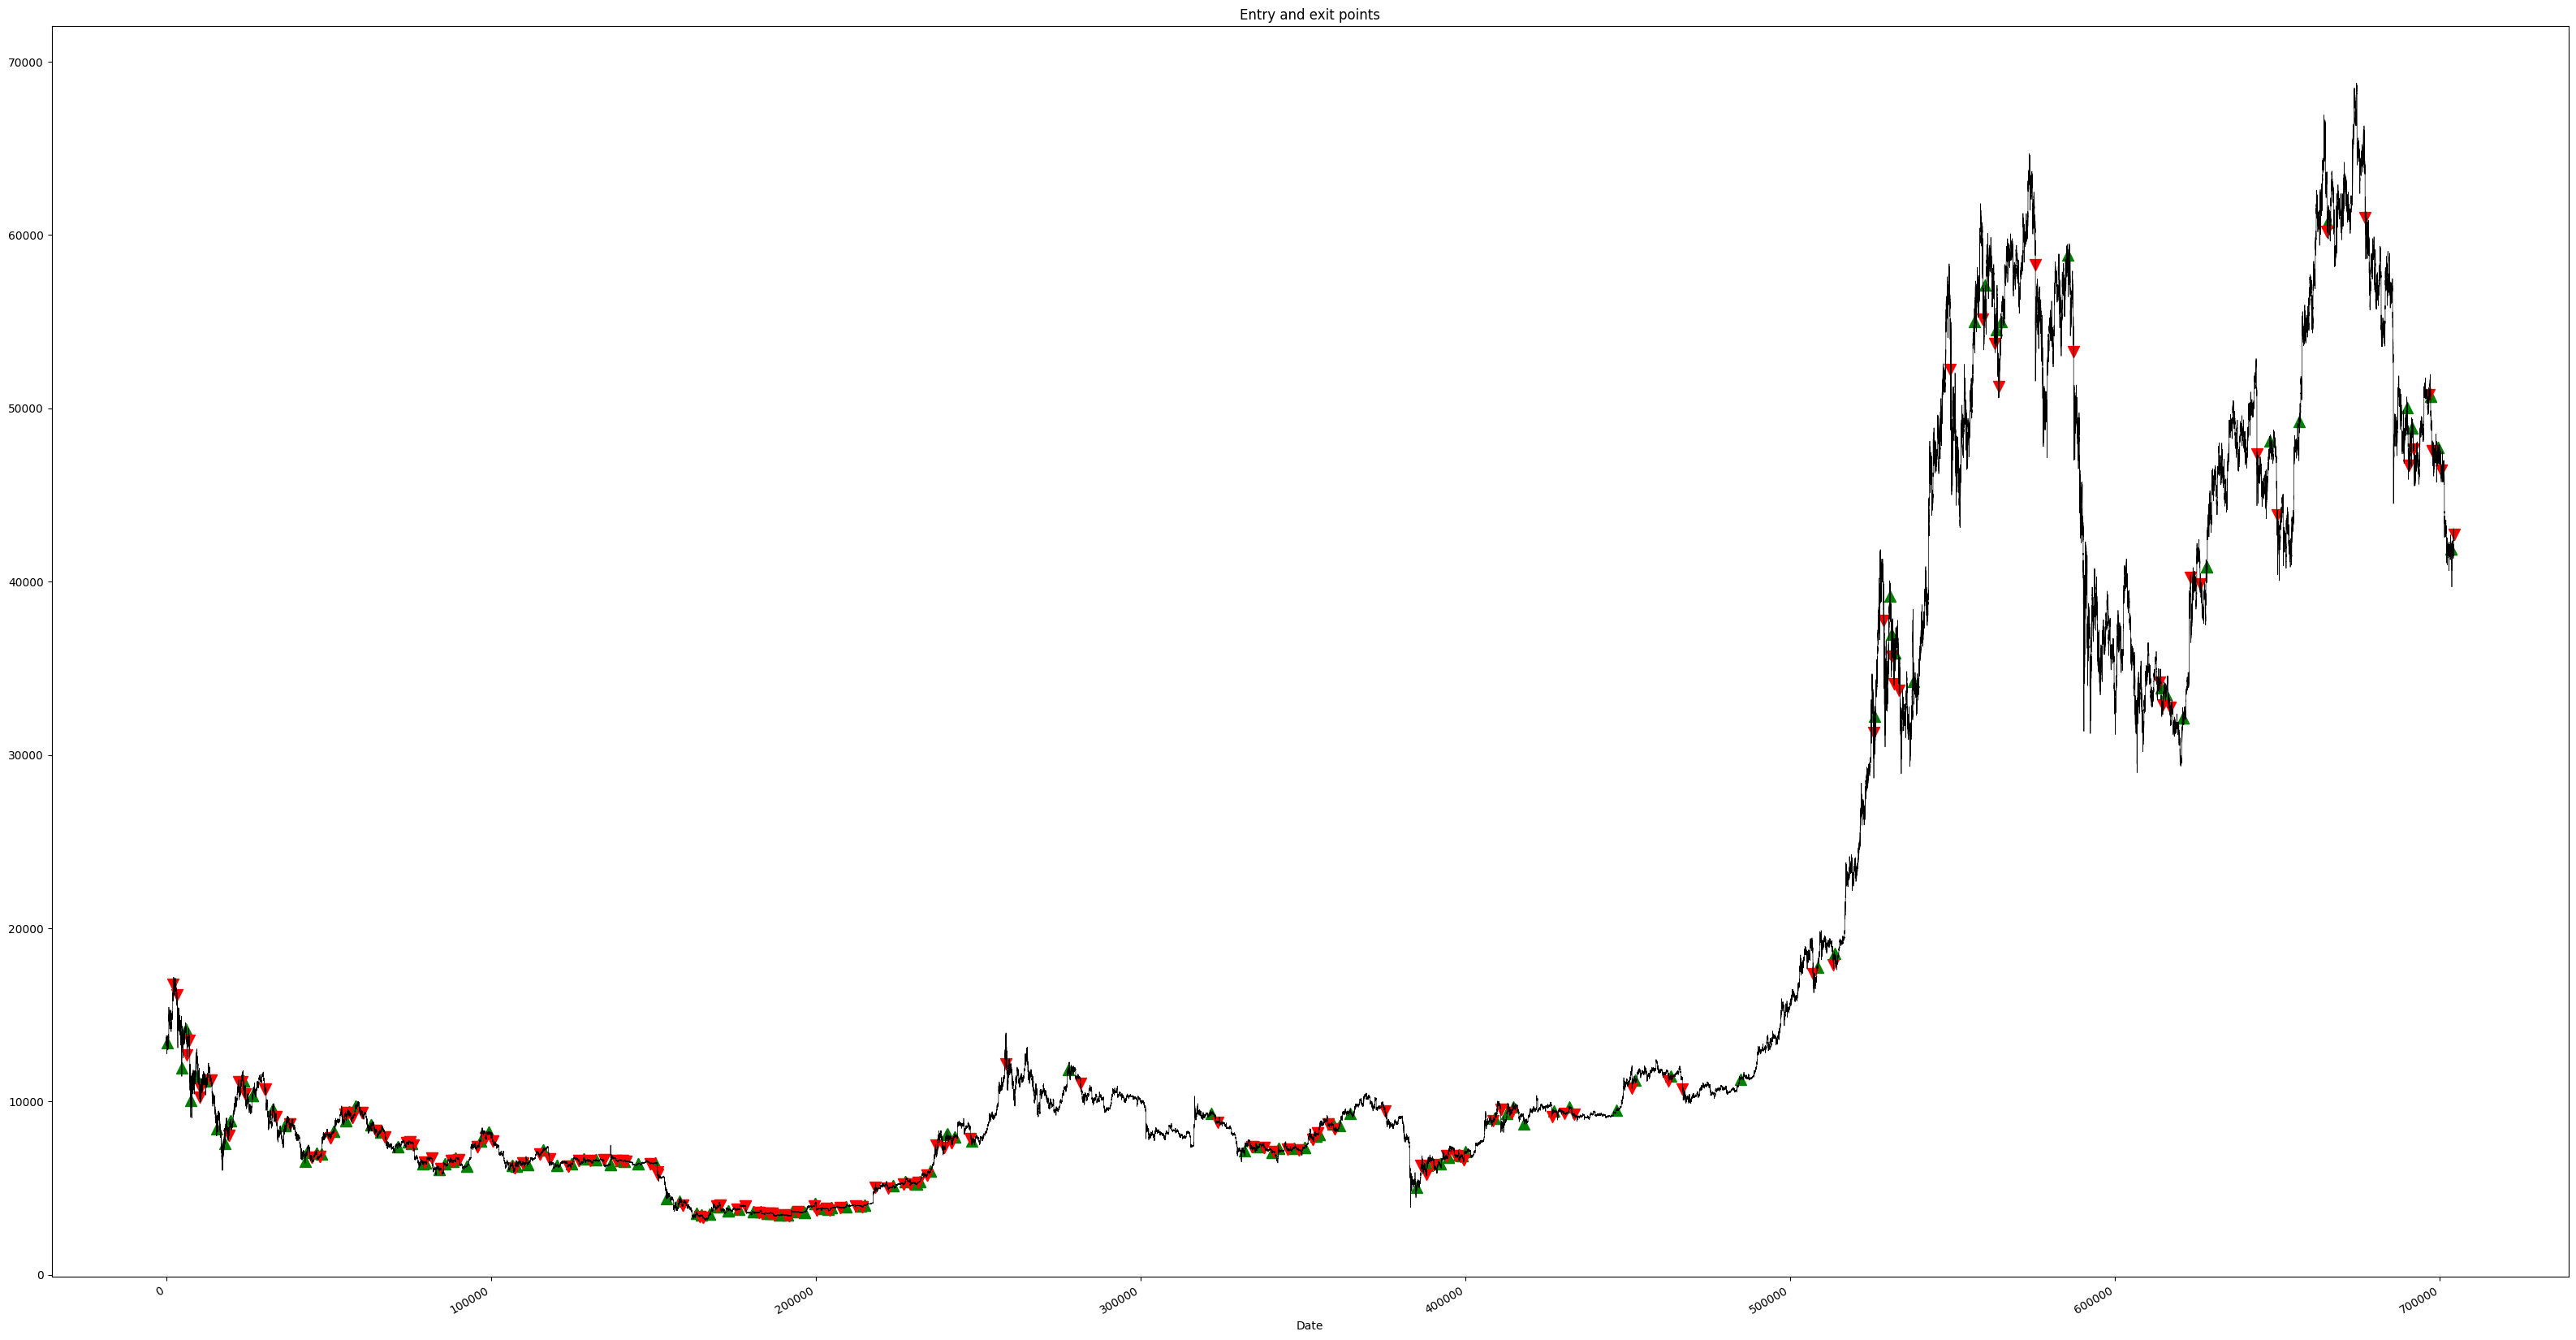

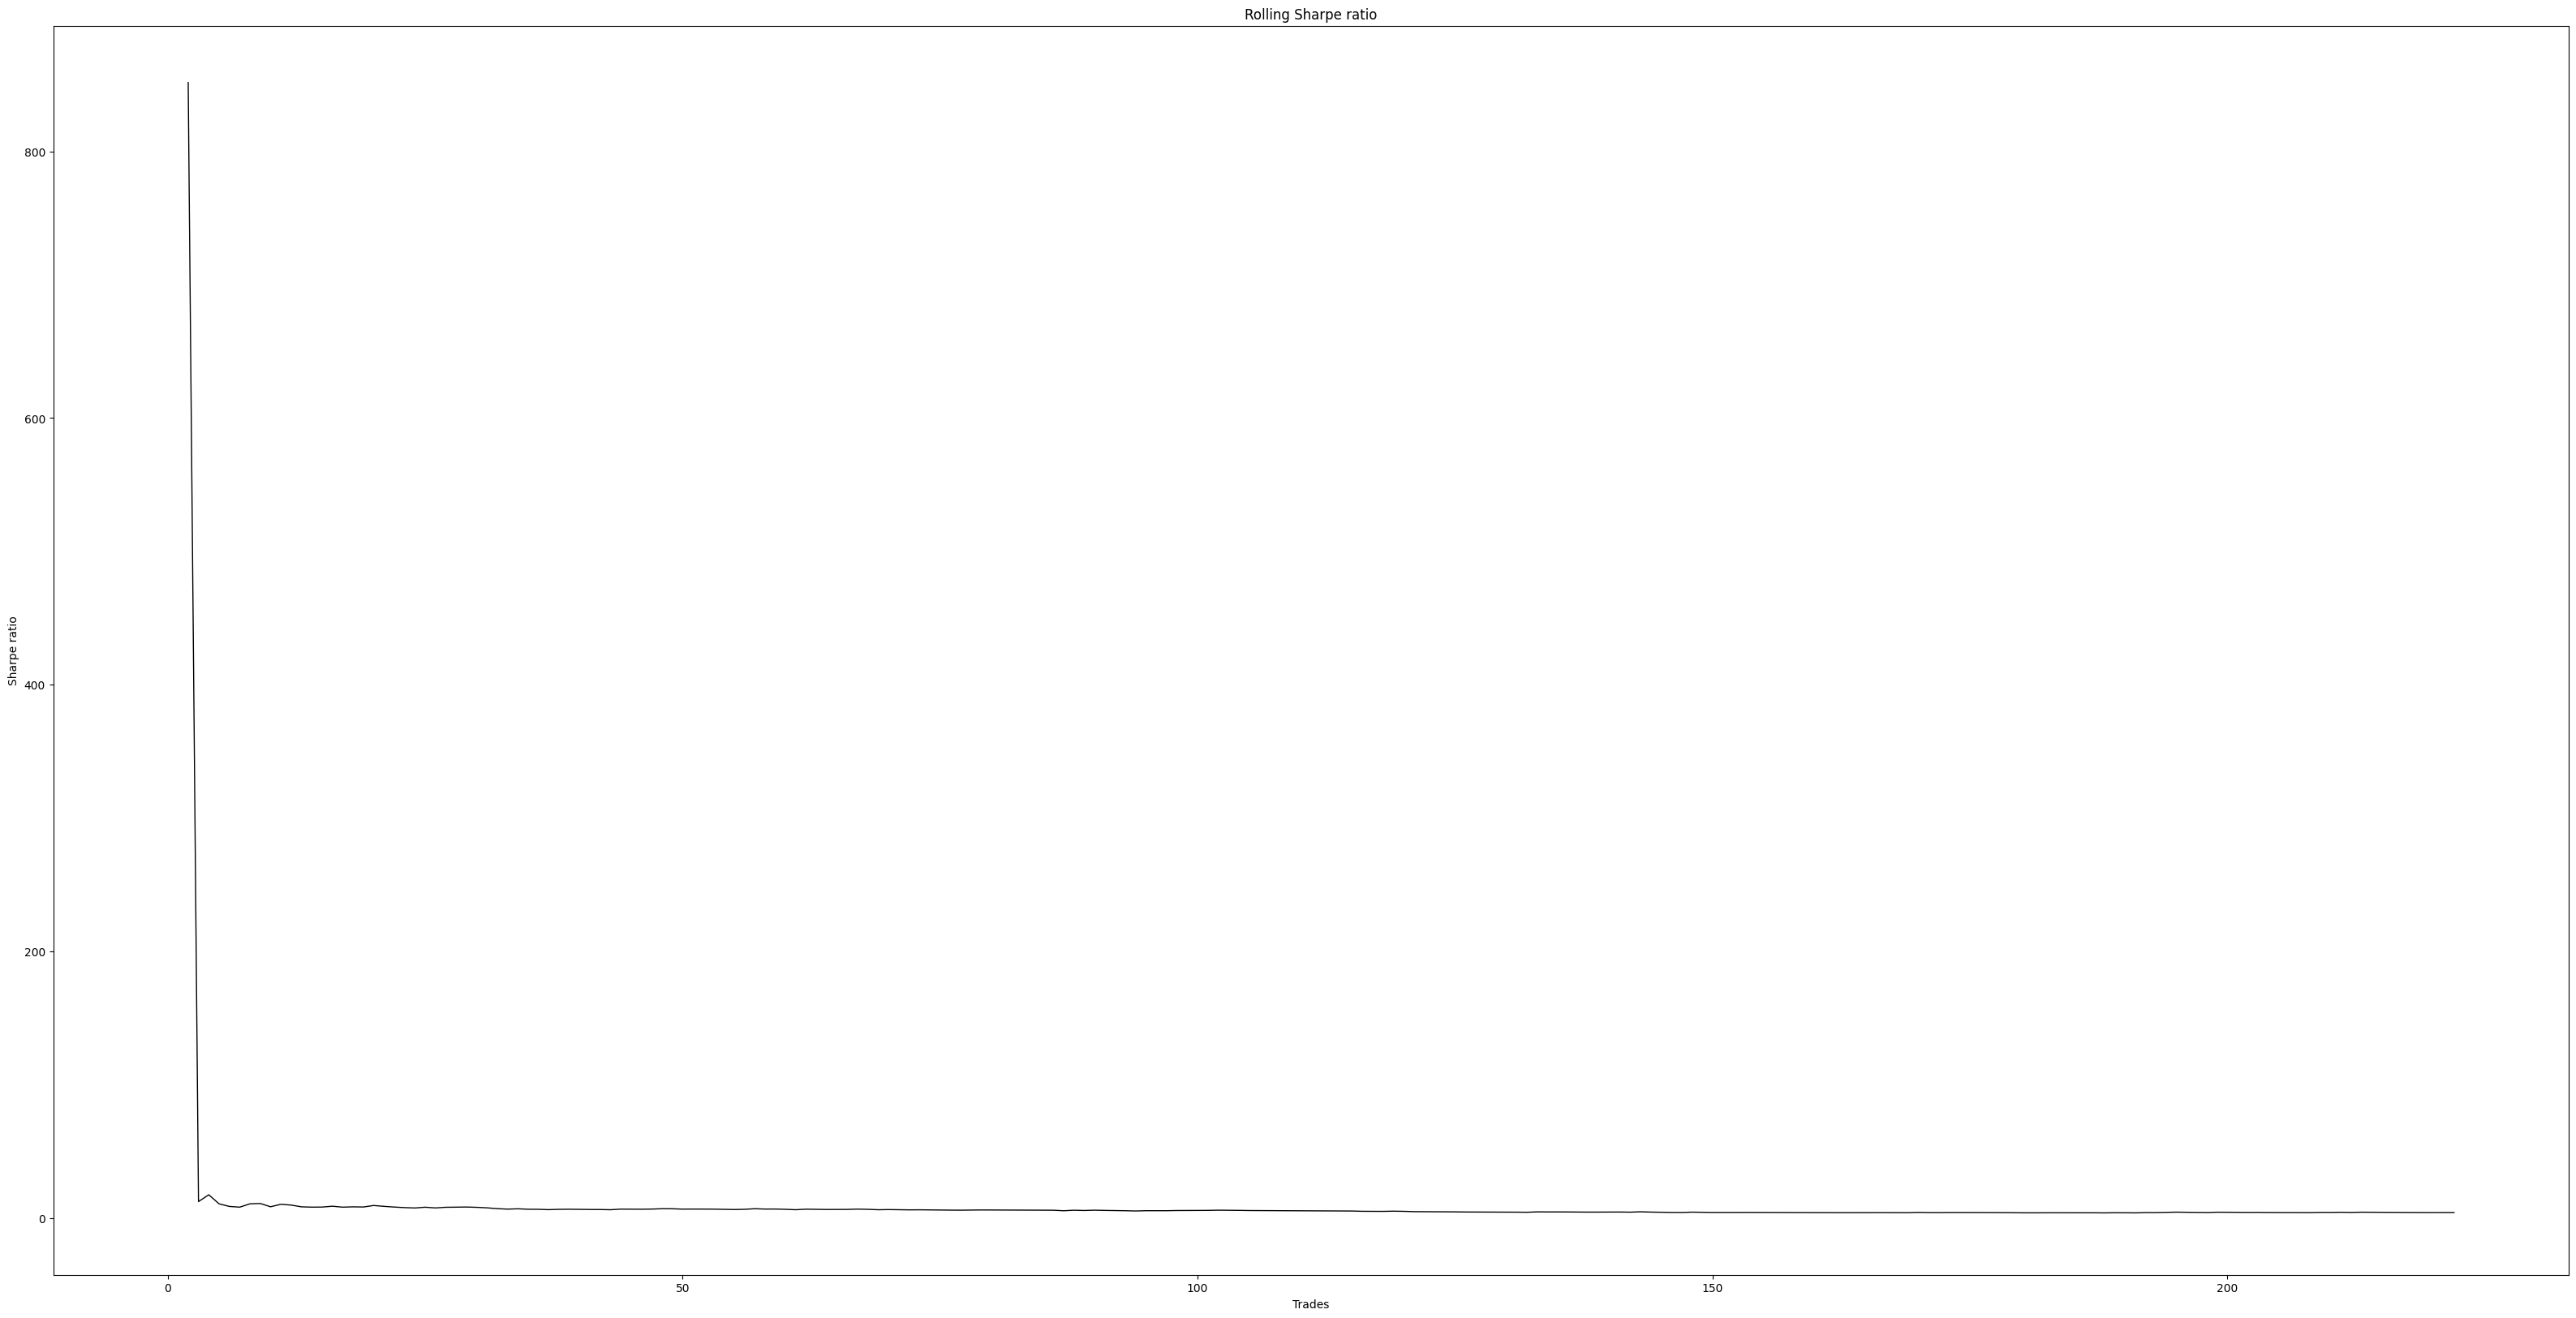

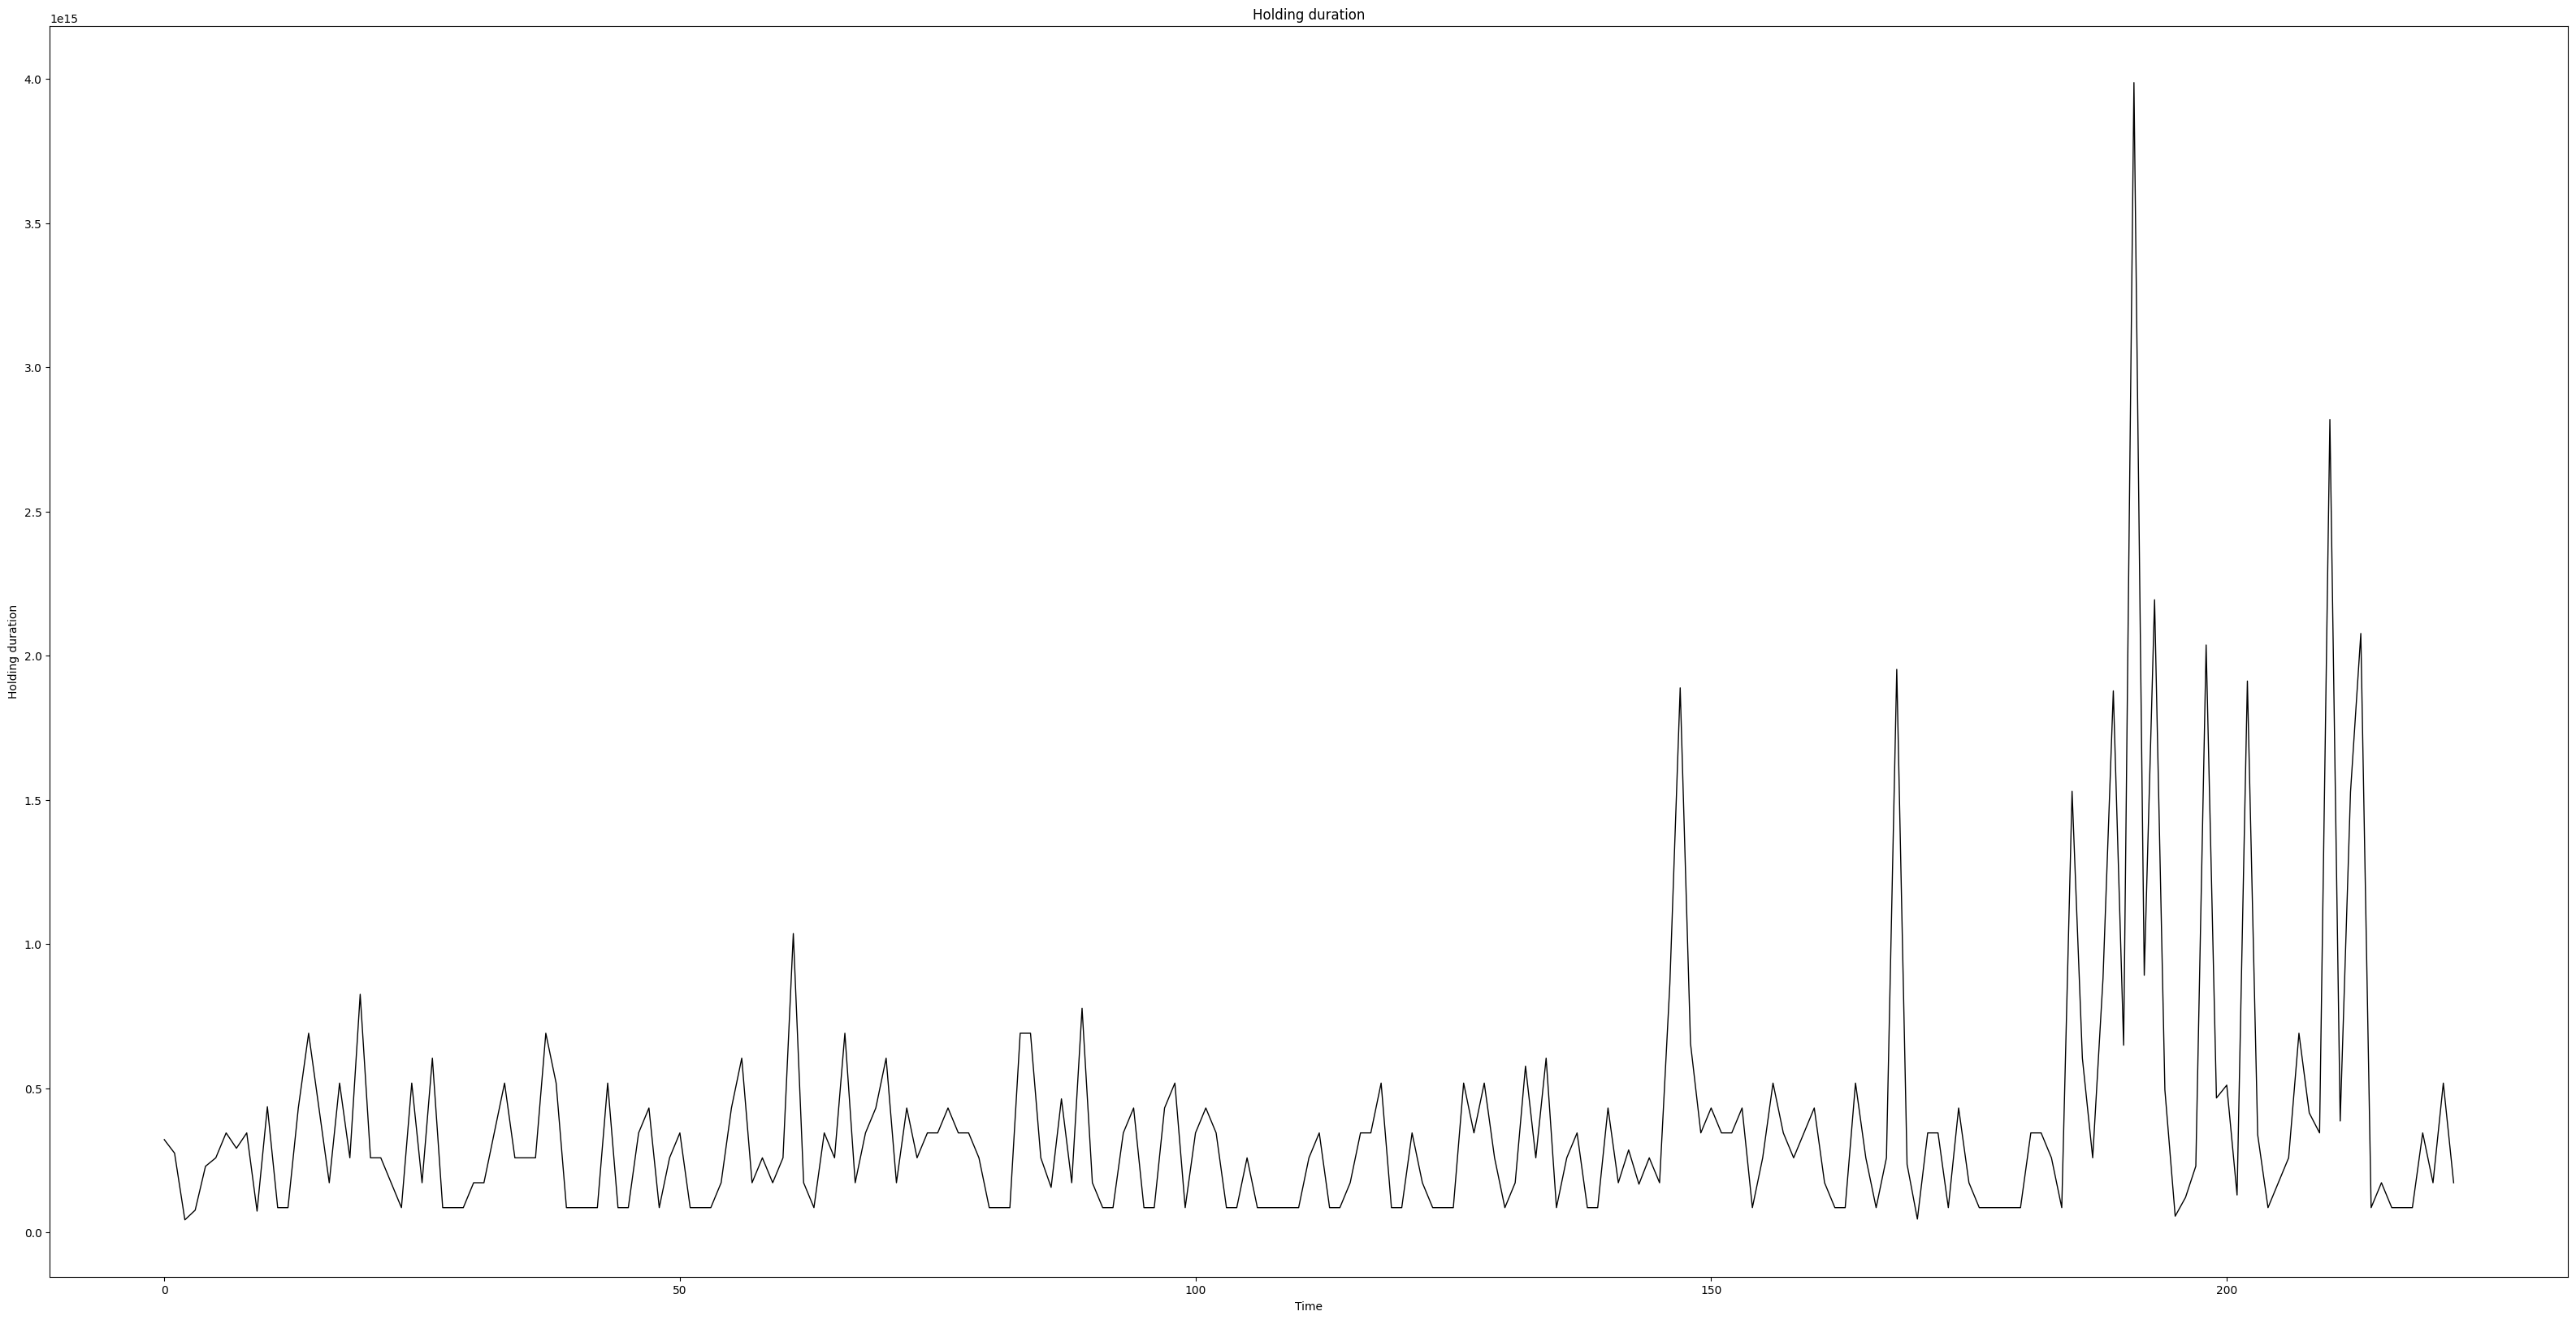

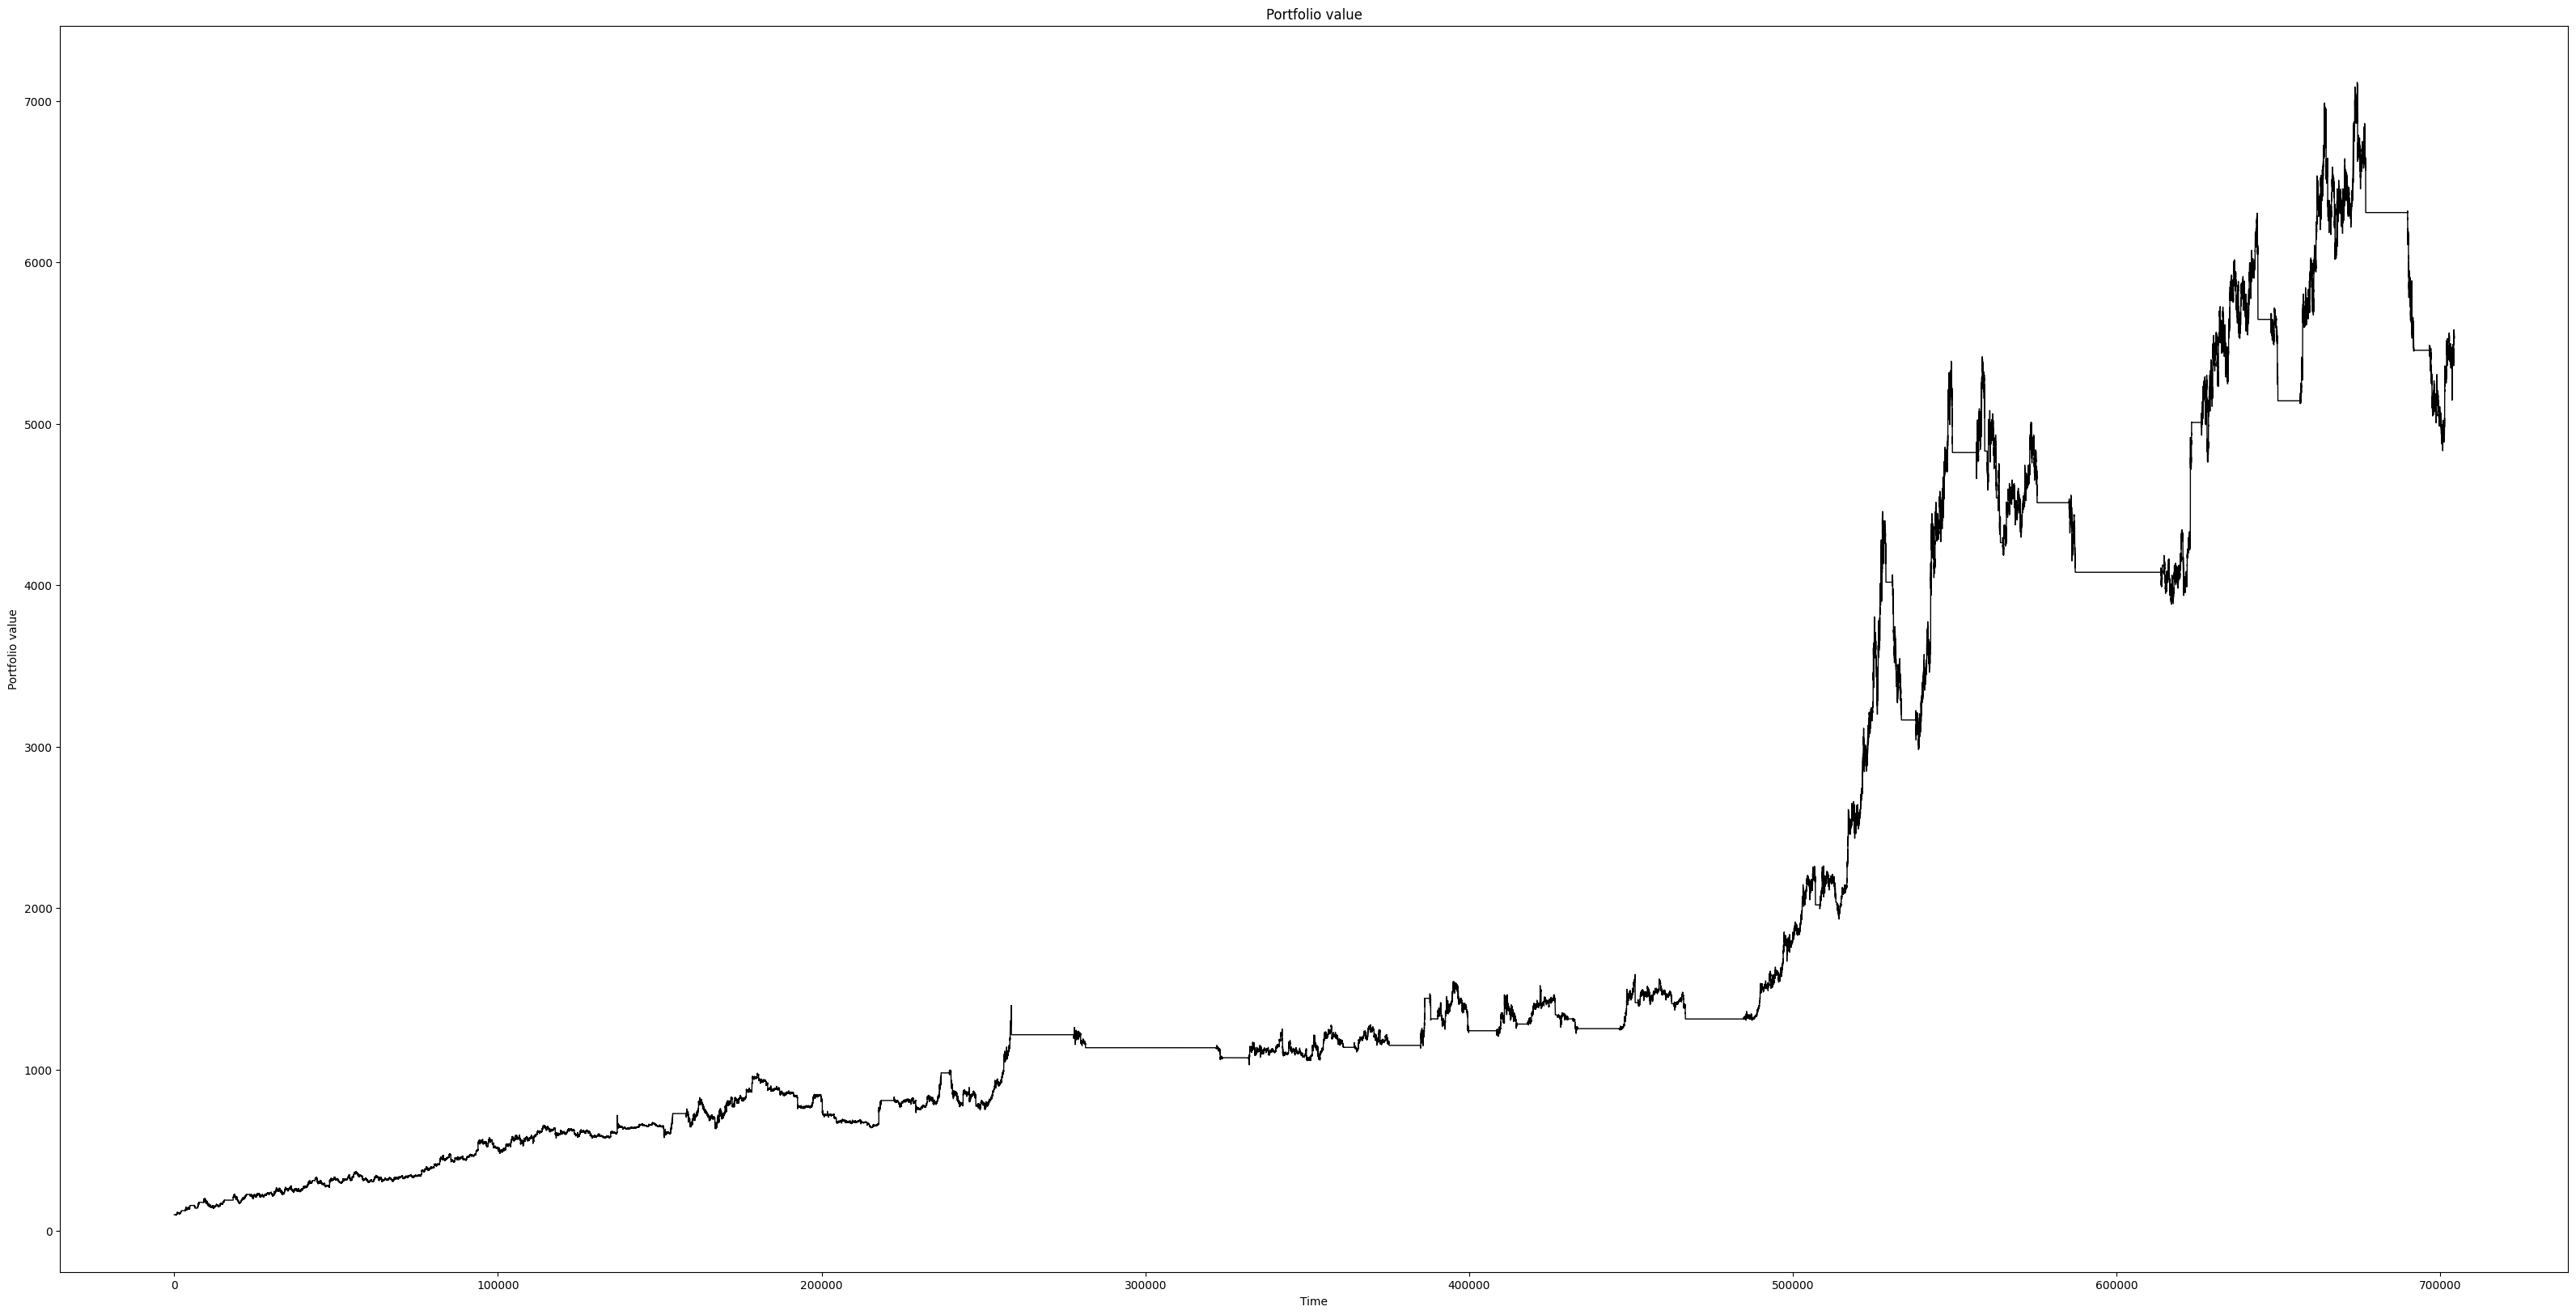

In [9]:
bt = Backtester(config)
results, stats, logs = bt.getBacktestingResults(tpsl_trades)

# Outsample
    start_date: '2022-01-13' | end_date: '2023-11-30'

In [10]:
config.utils.sample = "out_sample"

In [17]:
ohlcv_cheby, ohlcv_gmma_1w, ohlcv_gmma_1d, ohlcv_gran = load_ohlcv_data(config)

In [11]:
strat_cheby = StratCheby(ohlcv_cheby, ohlcv_gran, config)
cheby_trades = strat_cheby.run()

In [12]:
strat_gmma = MixedStratGMMA(ohlcv_gmma_1w, ohlcv_gmma_1d, ohlcv_gran, config)
gmma_trades, gmma_values = strat_gmma.run()

In [13]:
aligner = Aligner(cheby_trades, gmma_trades, config)
aligned_cheby_trades, aligned_gmma_trades = aligner.run()

In [14]:
ensemble = Ensemble(aligned_cheby_trades, aligned_gmma_trades, gmma_values, config)
ensemble_trades = ensemble.run()

100%|██████████| 329440/329440 [01:09<00:00, 4725.28it/s]


In [15]:
tpsl = TPSL(config)
tpsl_trades = tpsl.run(ensemble_trades)

Gross profit: 668.831561374193
Net profit: 370.5727665767499
Total closed trades: 148.0
Win rate: 43.91891891891892 %
Max dip: 12.265581823764201 %
Max runup: 29.14996344123706 %
Gross loss: 283.57212068856444
Average winning trade: 10.189617505059795
Average losing trade: -3.5150888102667084
Buy and hold return of BTC: -13.862137529599991
Largest winning trade: 101.72402836956093
Largest losing trade: -12.411996571728594
Sharpe ratio: 3.9226684308745354
Sortino ratio: 11.275734583142908
Average holding duration: 3 days 09:50:52.751677852
Max drawdown: -31.427895239166958


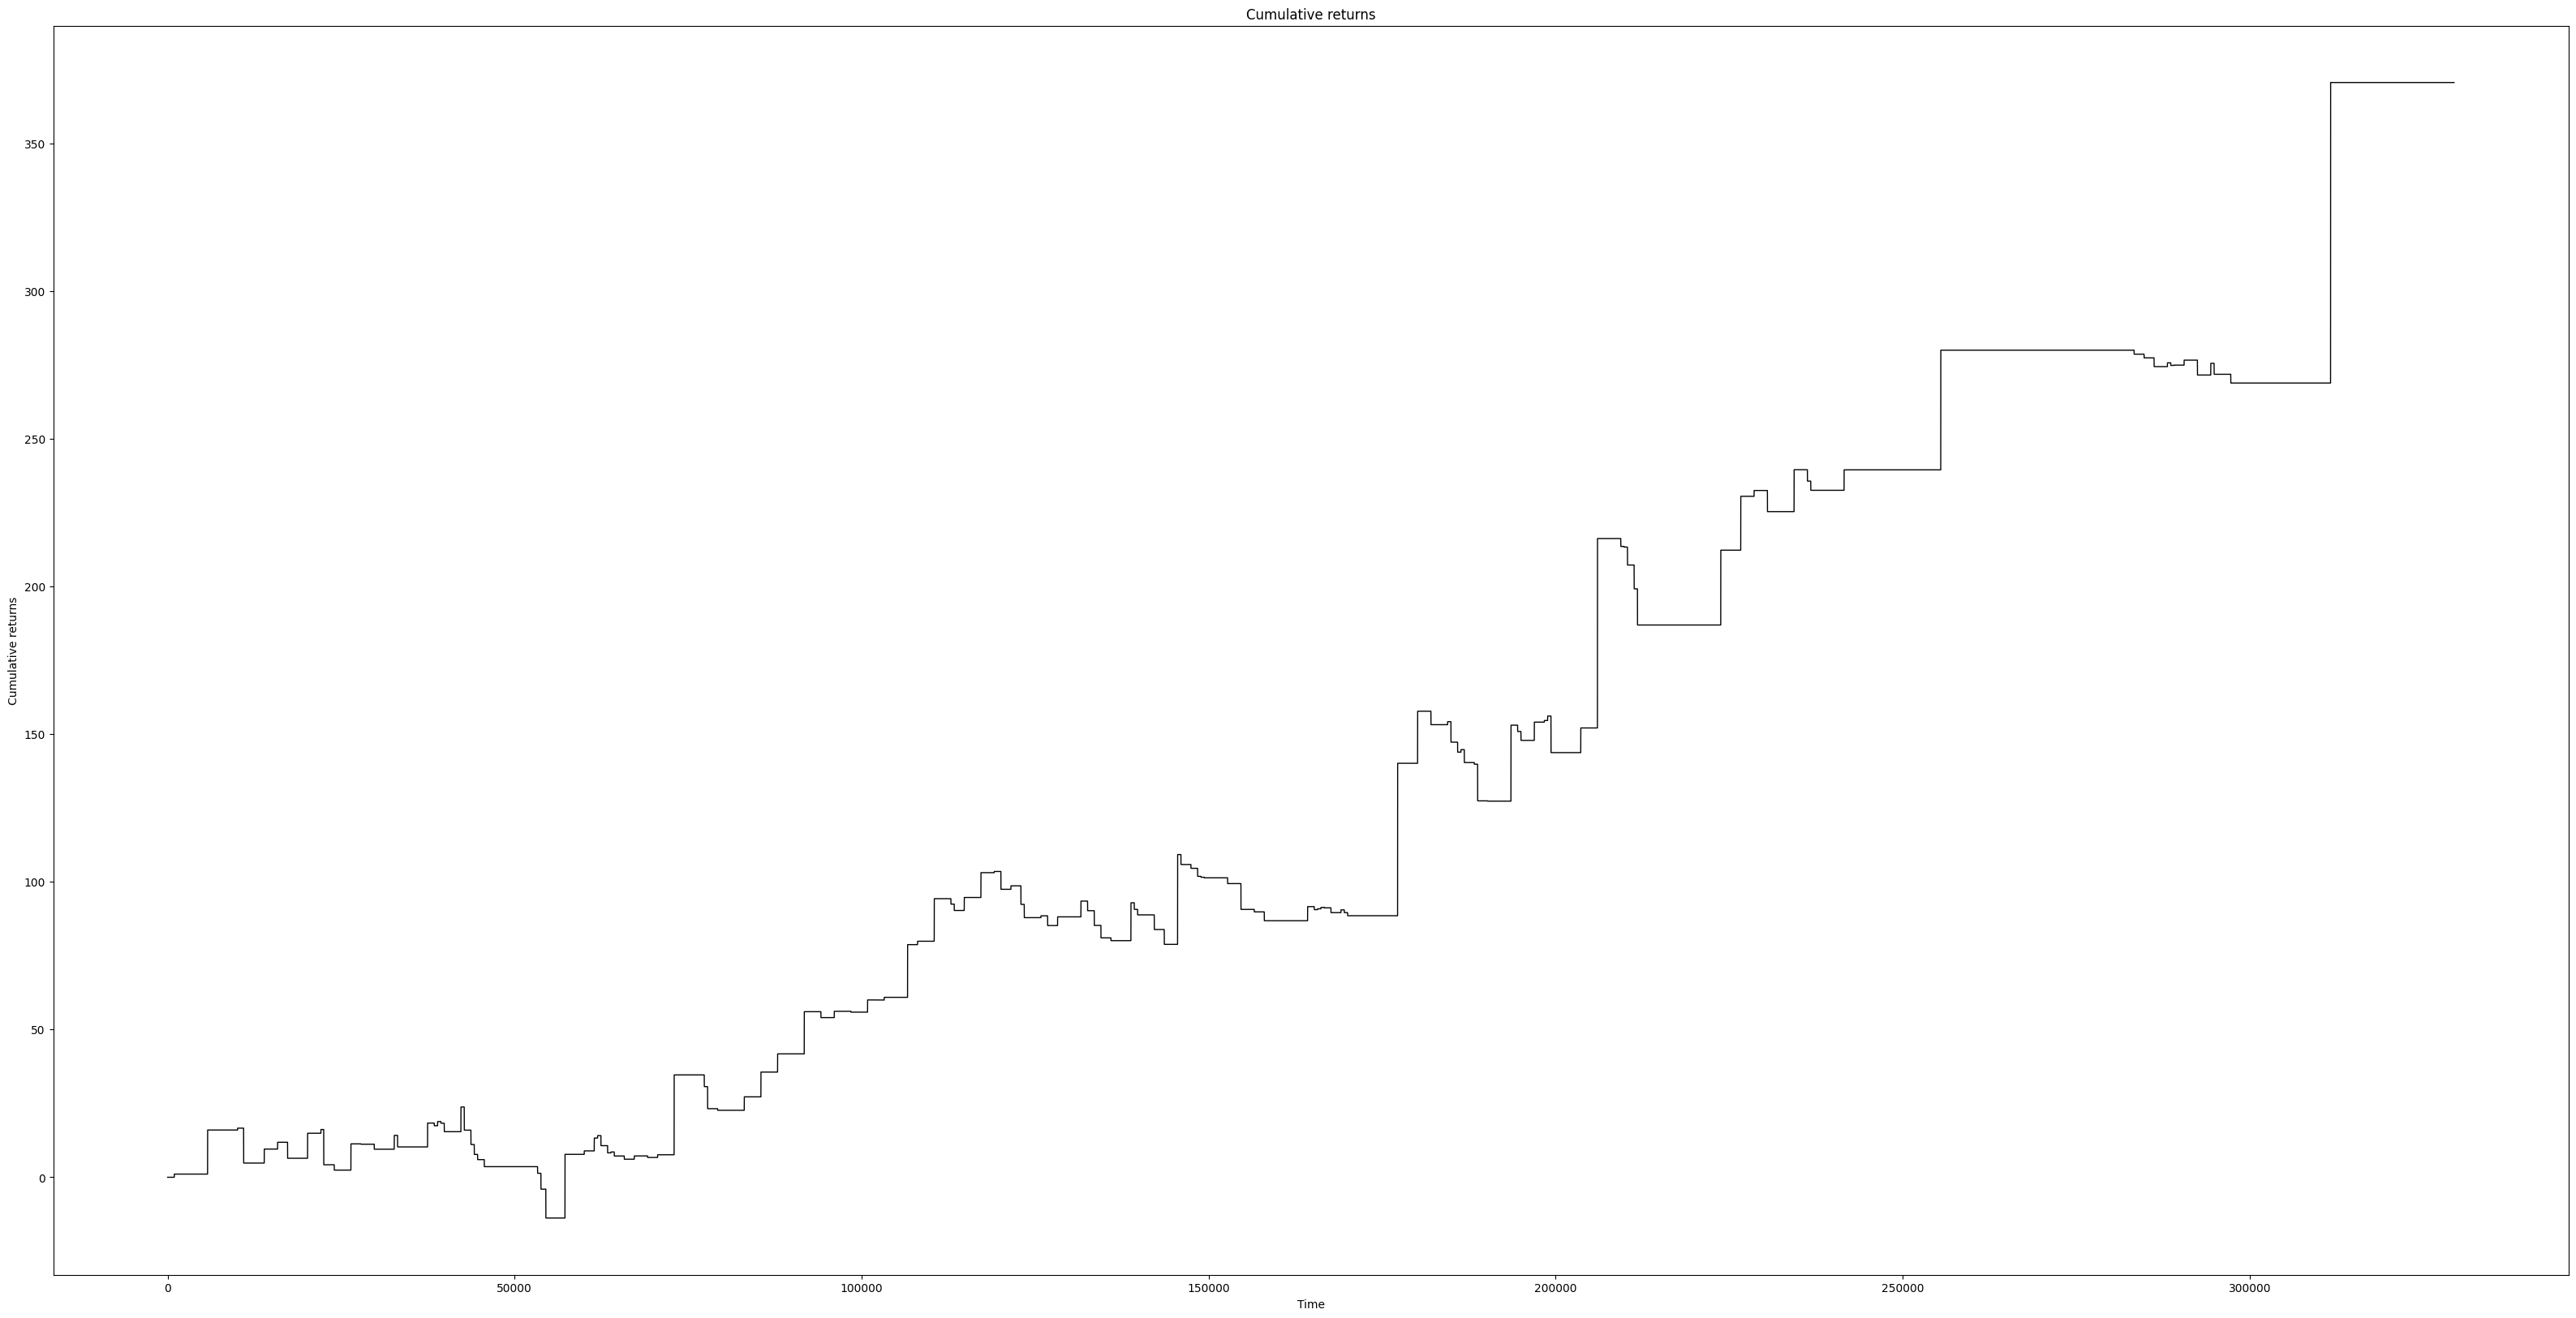

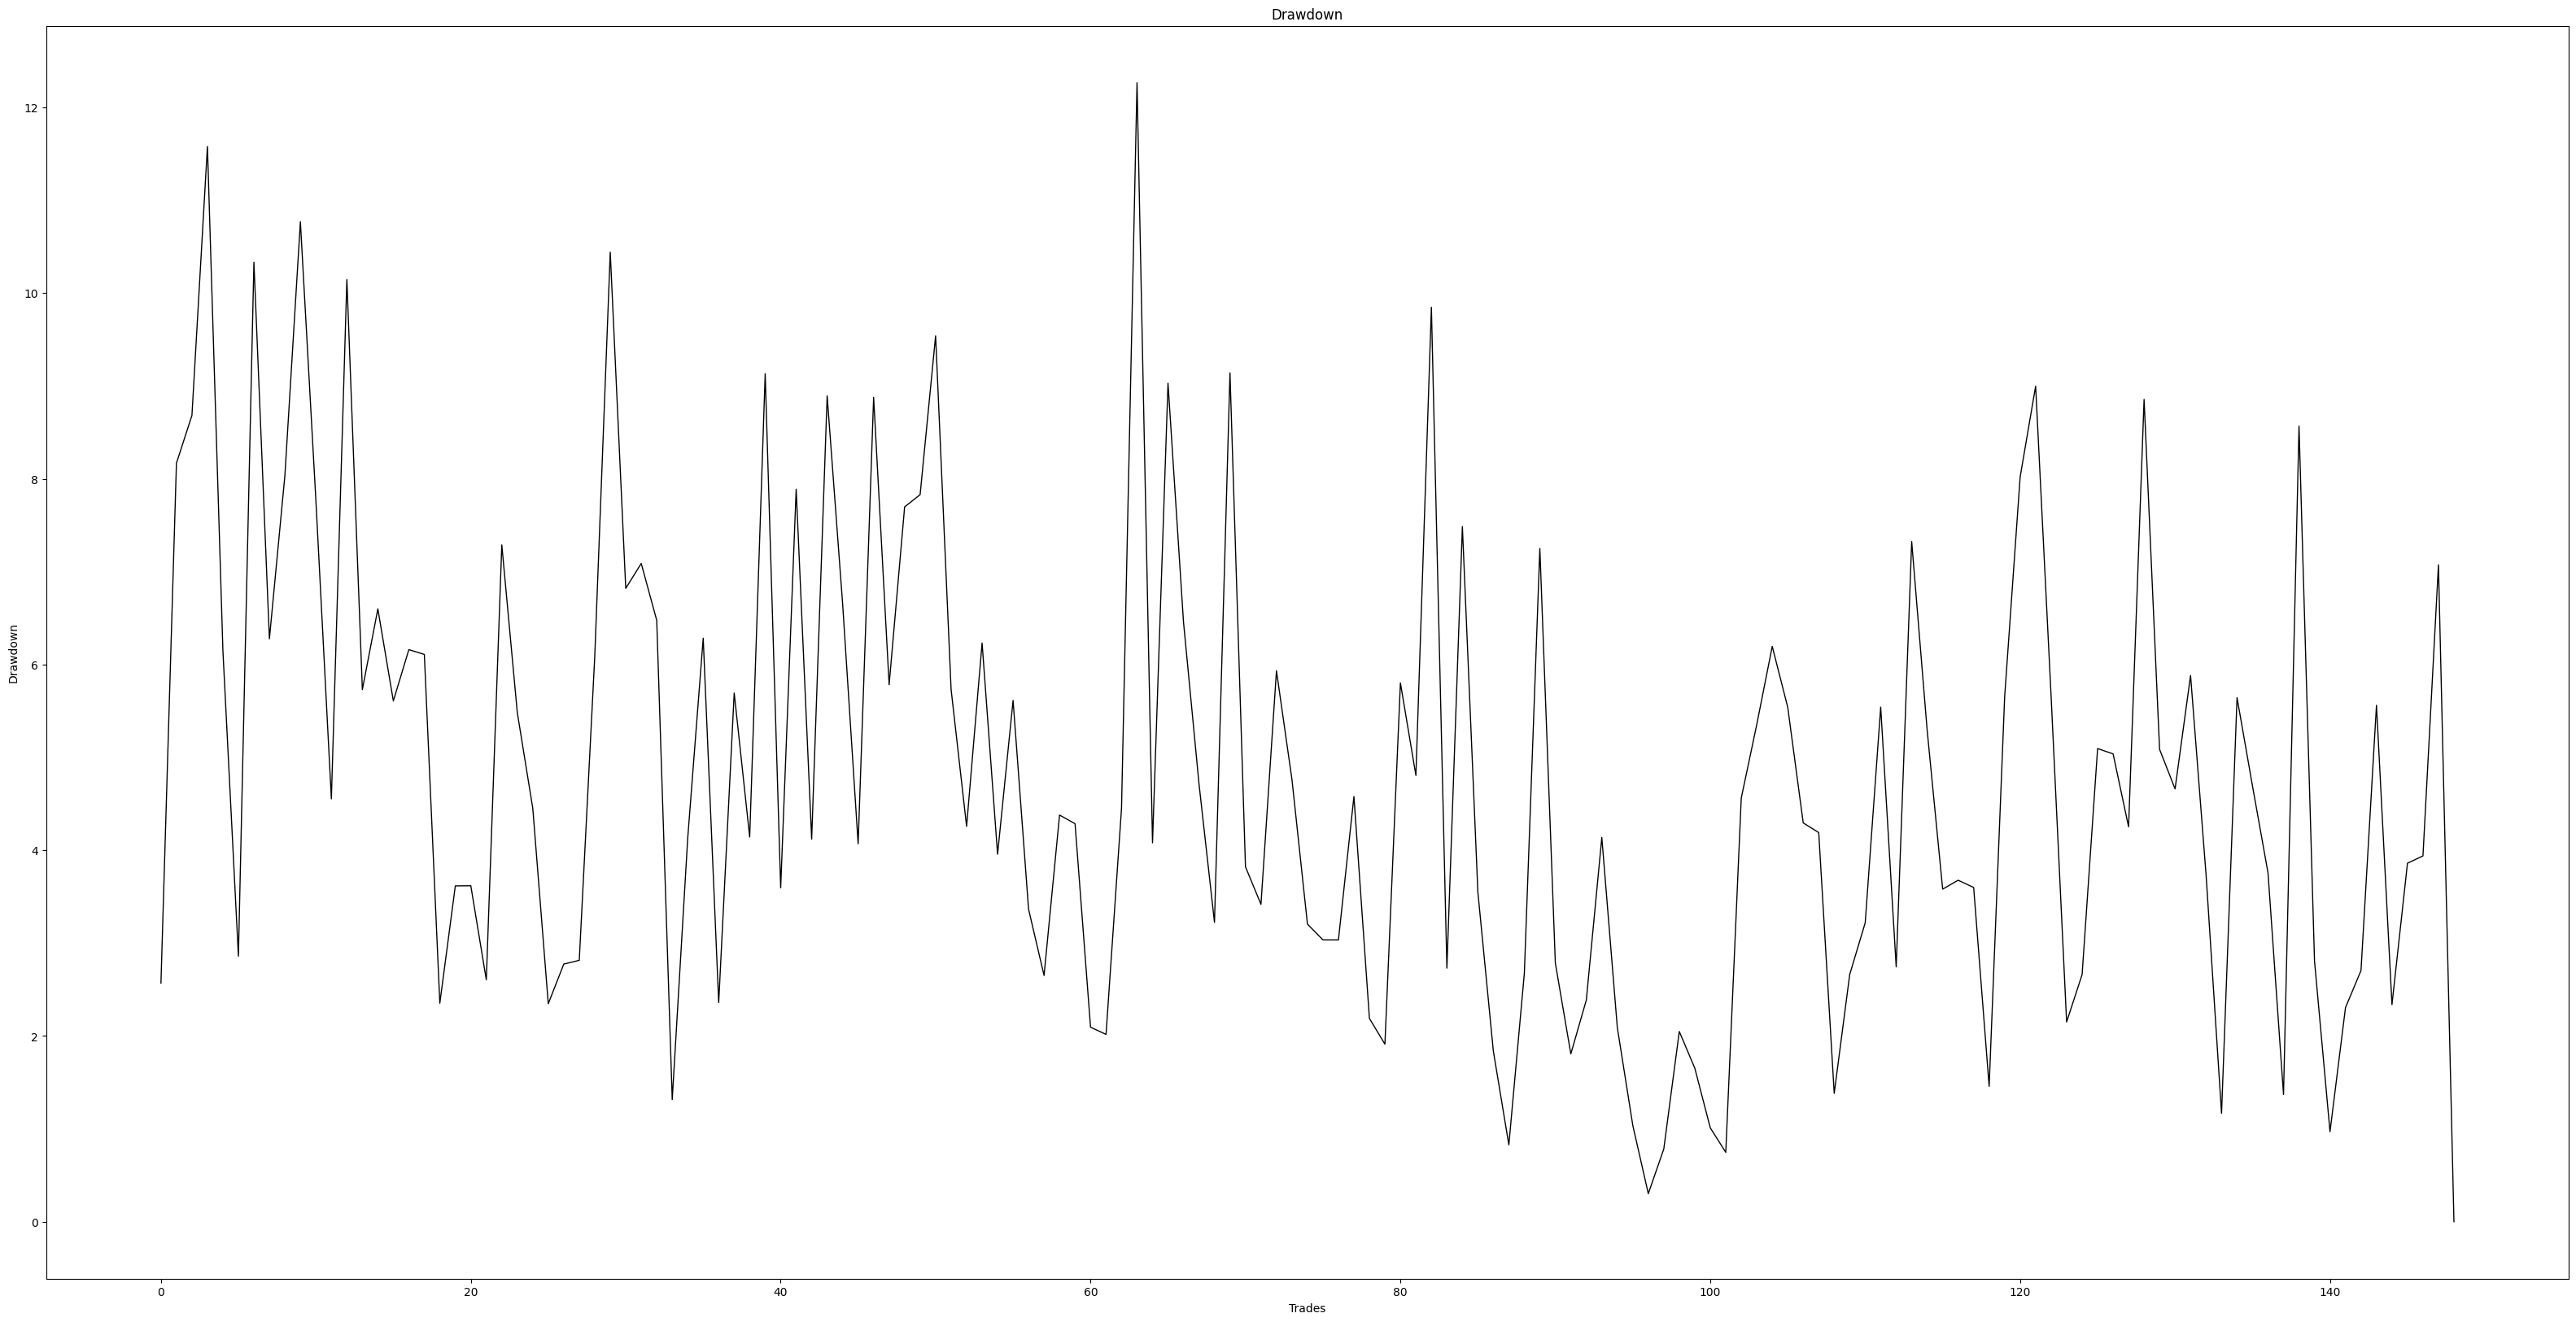

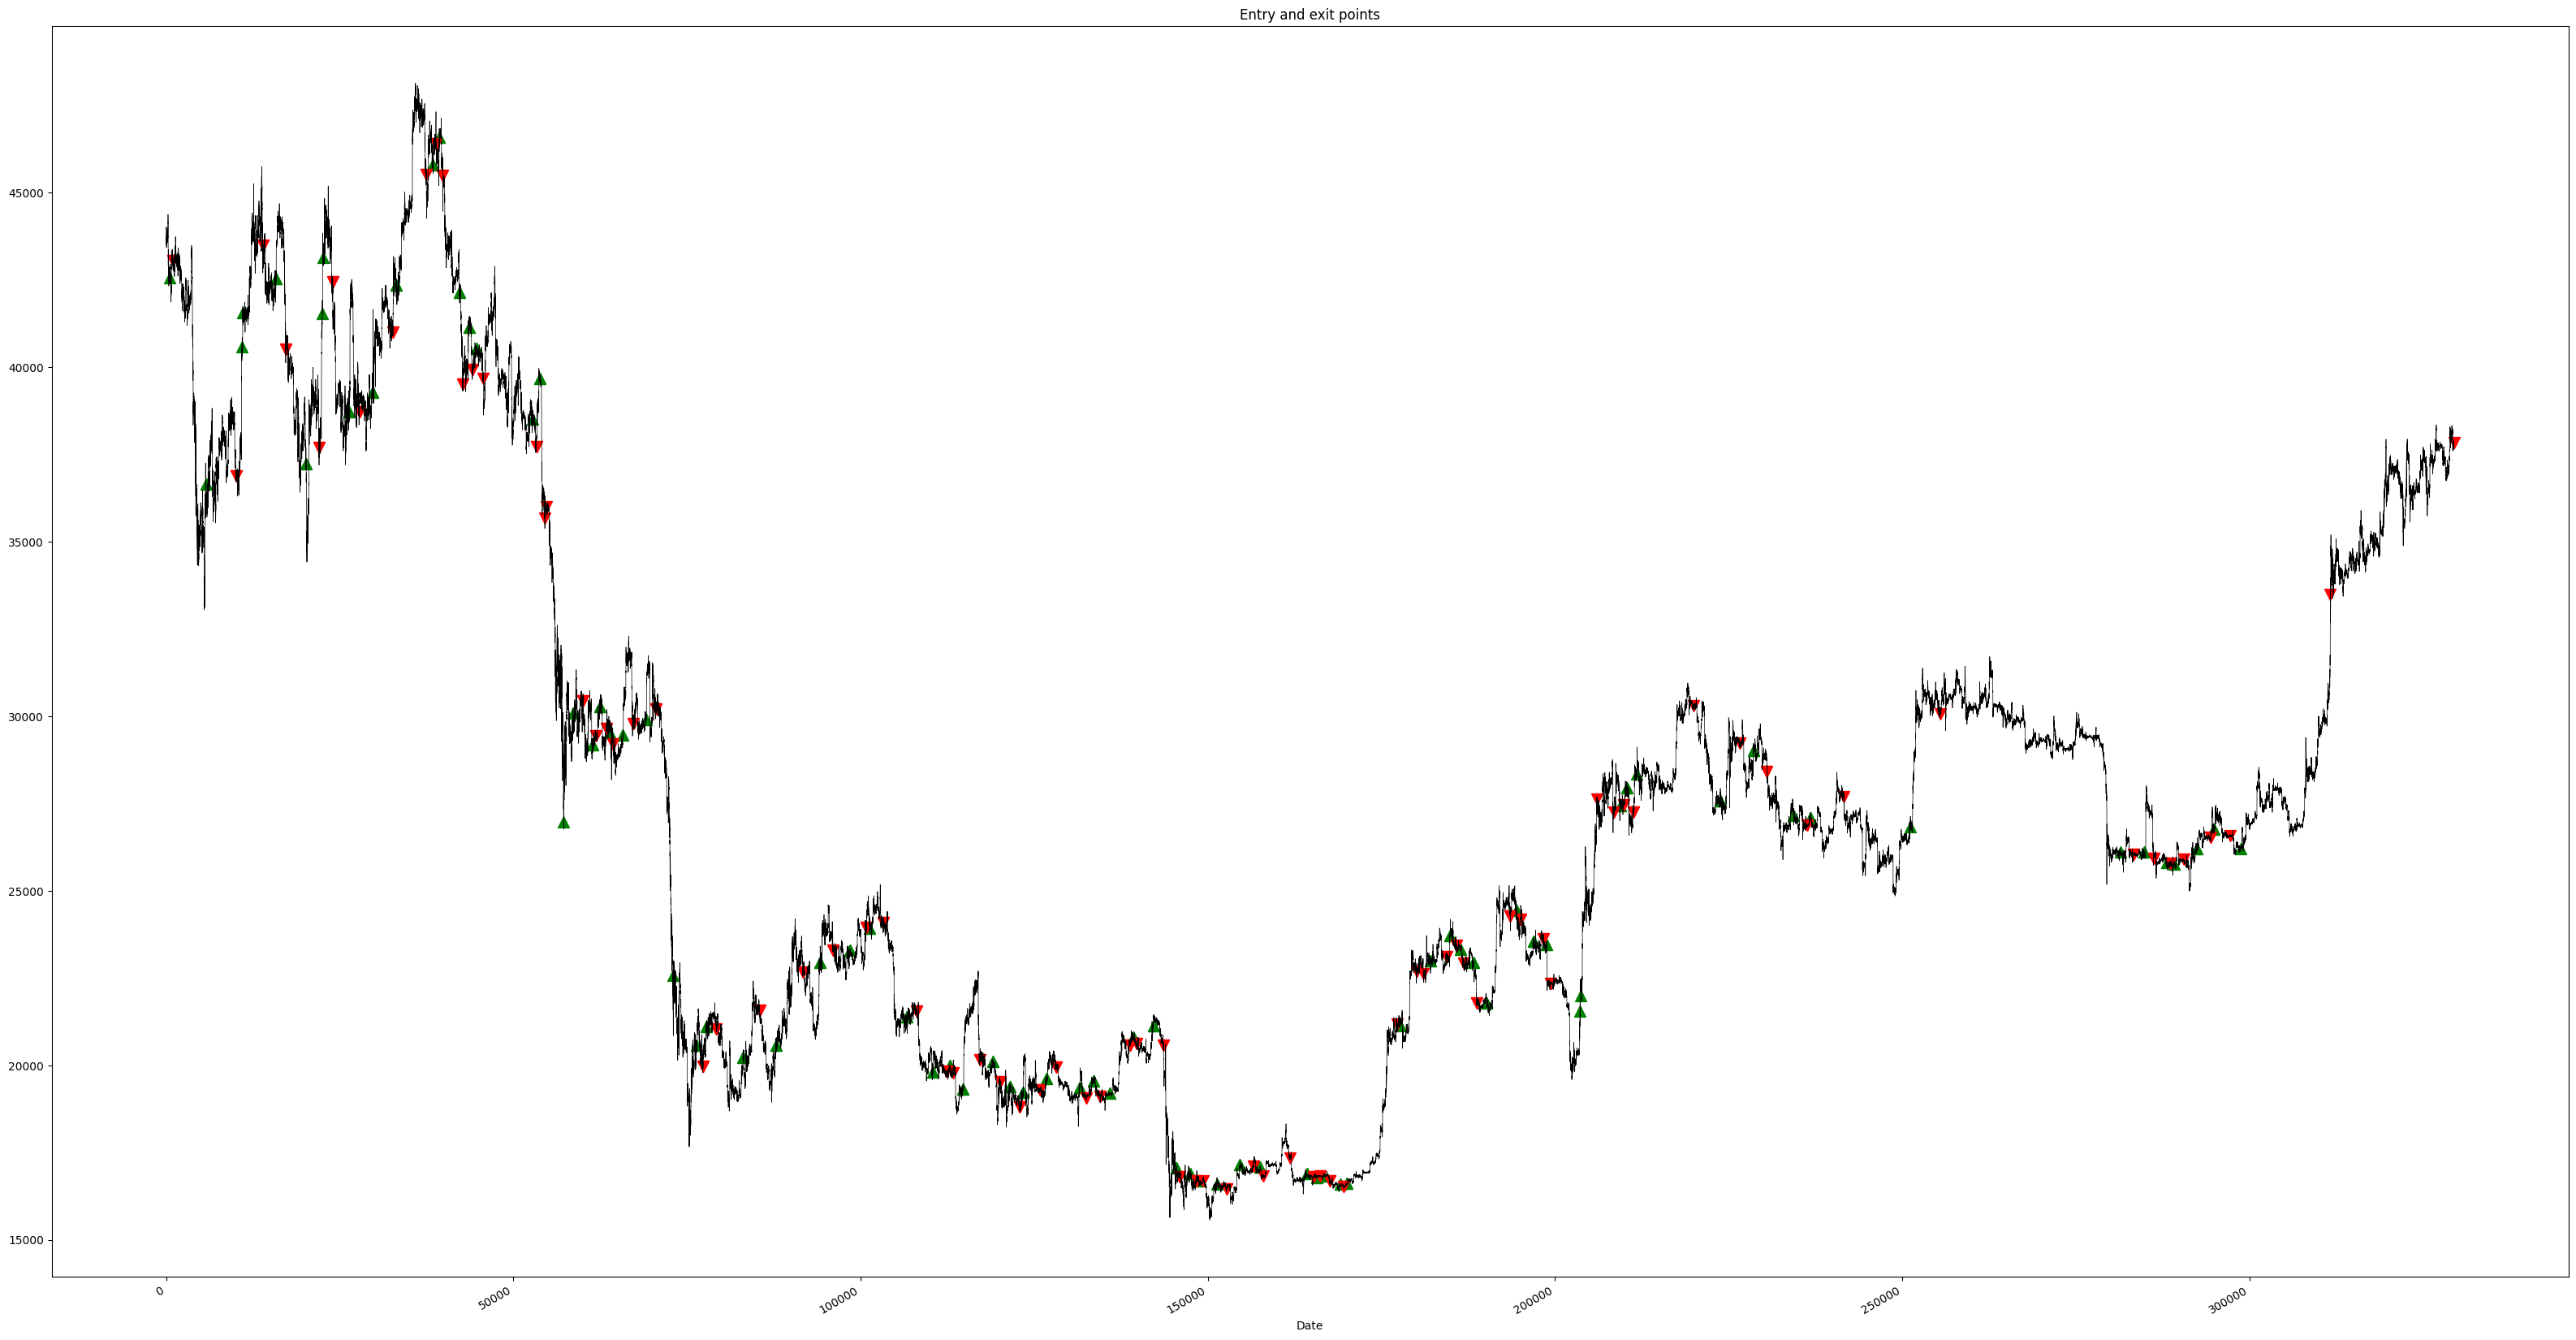

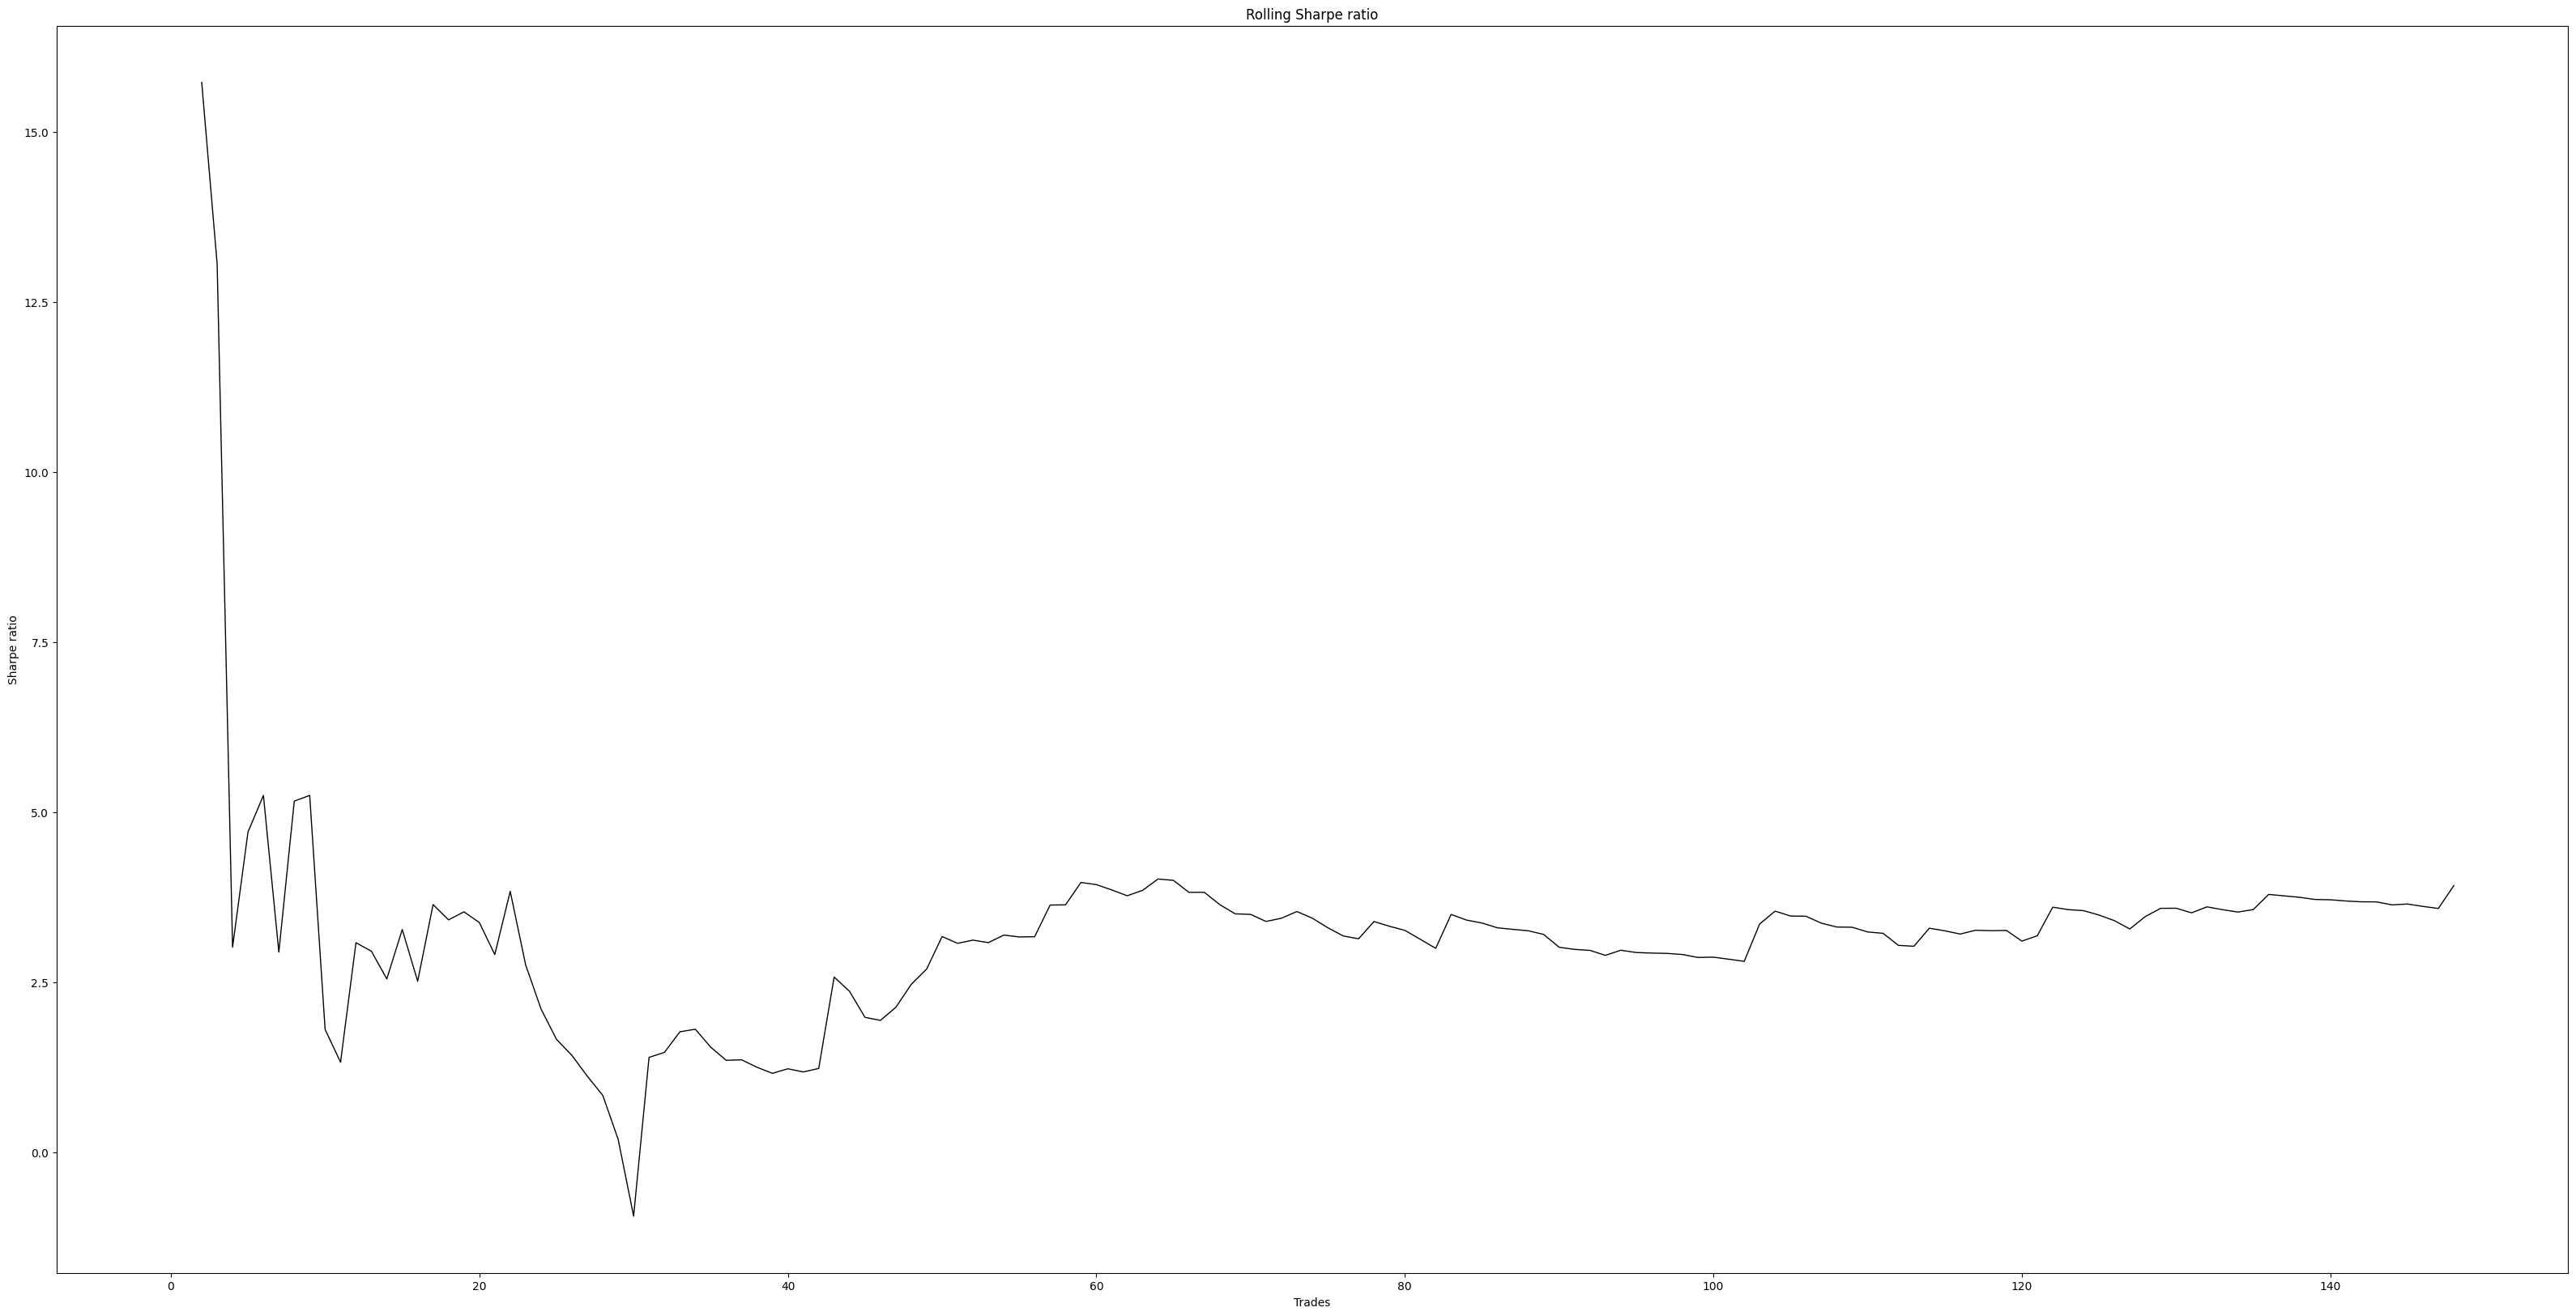

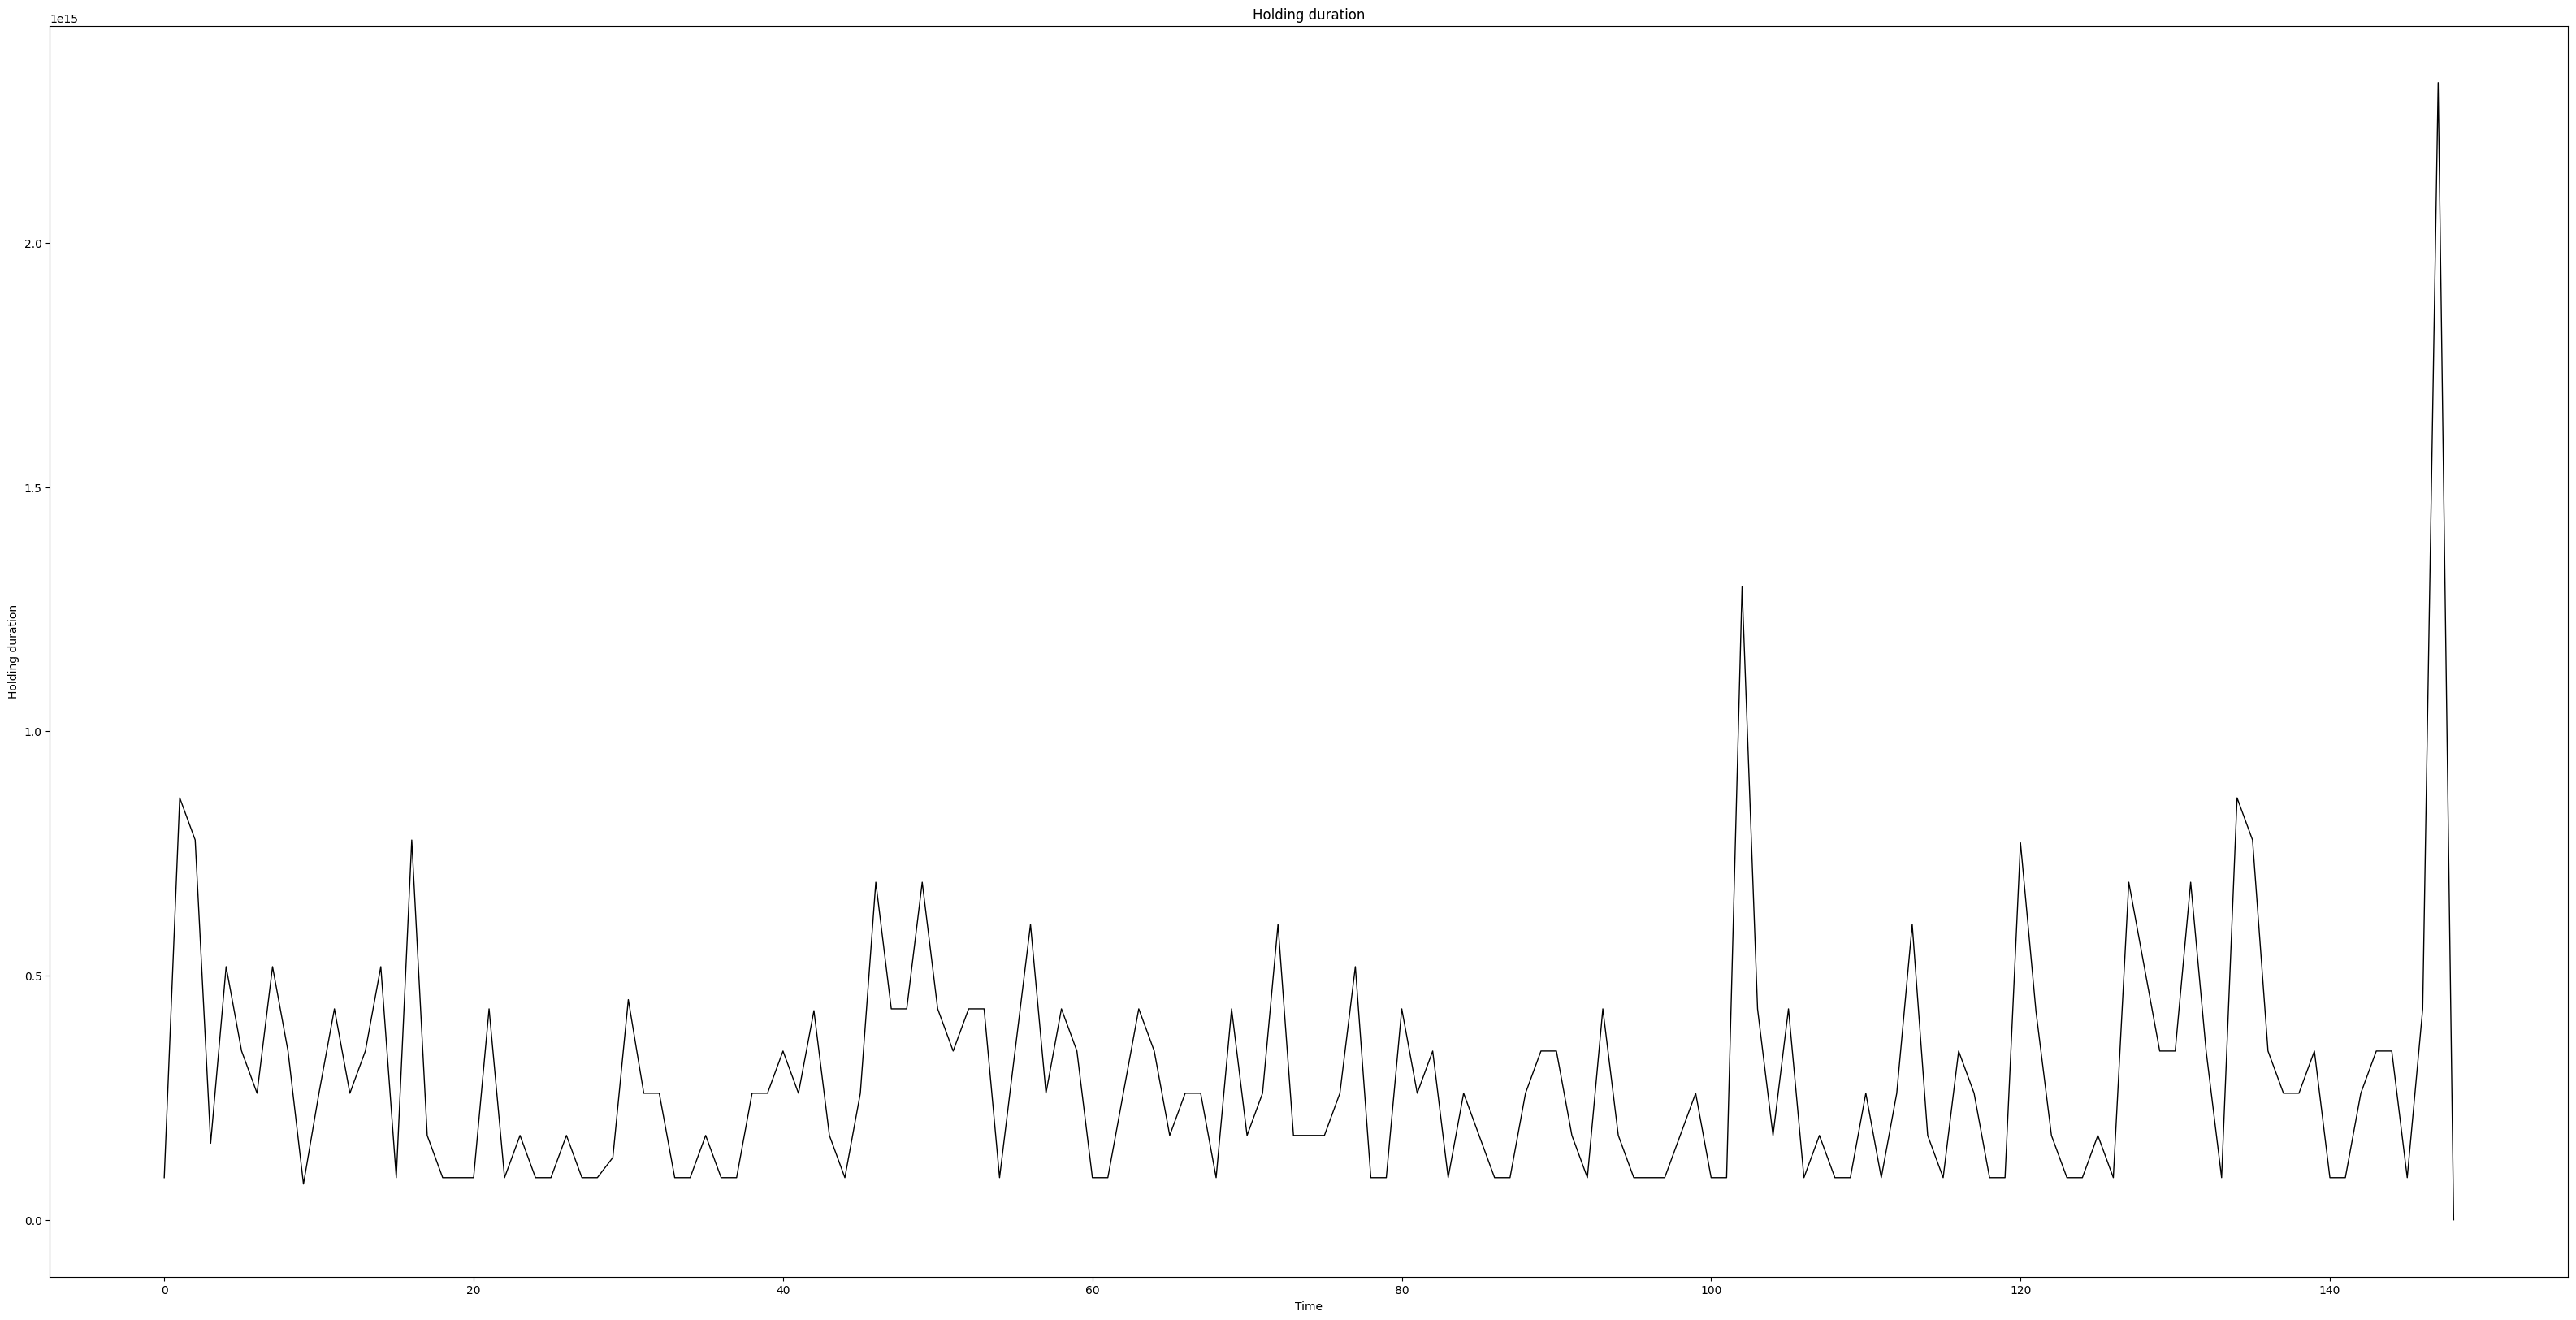

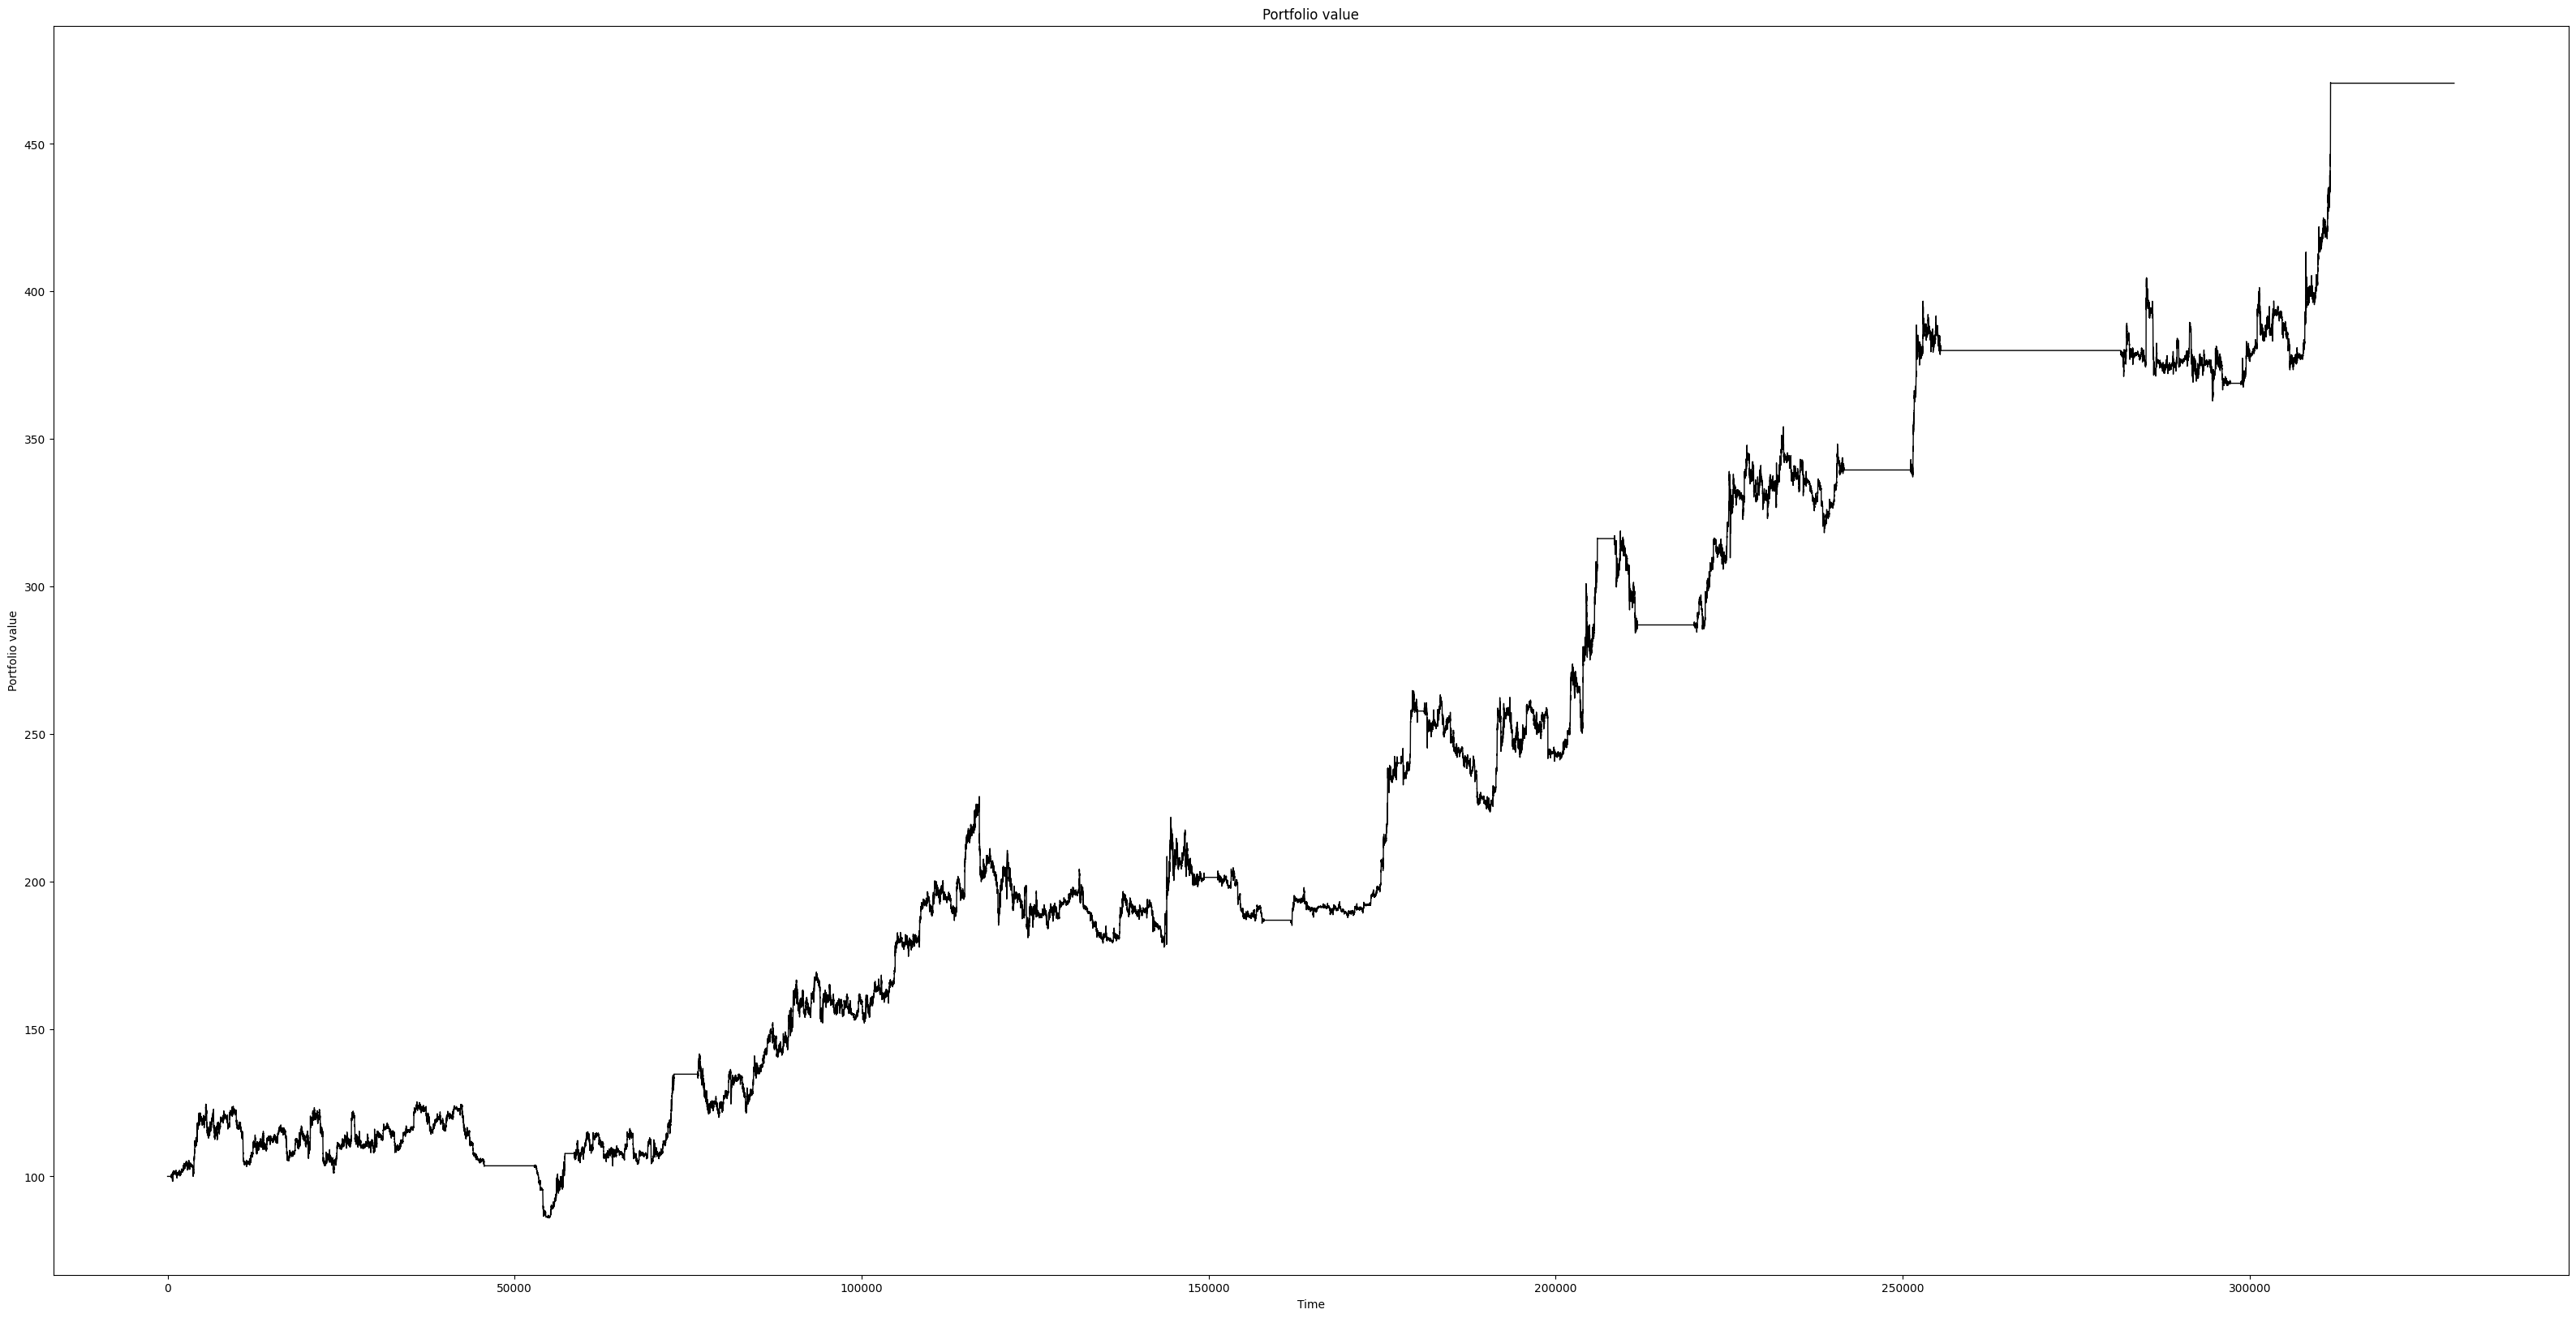

In [16]:
bt = Backtester(config)
results, stats, logs = bt.getBacktestingResults(tpsl_trades)